# Module C Milestone 1: Data Science Capstone
## Week 4 — Logistic Regression & Feature Scaling

**Methods covered:**
1. **Forward Stepwise Selection** — greedily adds the feature with best Test AUC gain
2. **Backward Stepwise Elimination** — greedily removes the least useful feature
3. **PCR (Principal Component Regression)** — PCA compression → LogisticRegression
4. **PLSR (Partial Least Squares Regression)** — supervised components → LogisticRegression

**Datasets:** Fraud Detection (deep-dive) · Credit Approval · Loan Default  
**Primary metric:** AUC-ROC | **Model upgrade:** LinearRegression (Week 3) → LogisticRegression (Week 4)

In [7]:
# ===========================================================================
# ALL IMPORTS
# ===========================================================================
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, recall_score, precision_recall_curve)

warnings.filterwarnings('ignore')

DATA_DIR              = r'E:\BU\CDSDX 699 O2\data'
CARDINALITY_THRESHOLD = 50

# Shared settings: search phase (fast) vs. final CV (thorough)
LR_SEARCH = dict(solver='saga', max_iter=100, n_jobs=-1, C=1.0)
LR_CV     = dict(Cs=[0.01, 0.1, 1.0, 10.0, 100.0], cv=3, solver='saga',
                 max_iter=300, n_jobs=-1, scoring='roc_auc')

# Suppress BEL character in notebook output
_orig_write = sys.stdout.write
sys.stdout.write = lambda s: _orig_write(s.replace('', '').replace('', ''))

print('Week 4 workspace initialized.')

Week 4 workspace initialized.


In [8]:
# ===========================================================================
# HELPER FUNCTIONS — LogisticRegression replaces LinearRegression throughout
# ===========================================================================

def forward_stepwise(X_train, X_test, y_train, y_test, feat_names, max_steps=25, patience=3):
    """Greedy forward selection (LogisticRegression, predict_proba AUC)."""
    X_train = np.asarray(X_train); X_test = np.asarray(X_test)
    remaining = list(range(X_train.shape[1]))
    selected = []; best_auc = 0.0; best_subset = []; no_improve = 0; records = []
    for _ in range(min(max_steps, len(remaining))):
        step_best_auc = -1; step_best_idx = None
        for idx in remaining:
            trial = selected + [idx]
            clf = LogisticRegression(**LR_SEARCH)
            clf.fit(X_train[:, trial], y_train)
            auc = roc_auc_score(y_test, clf.predict_proba(X_test[:, trial])[:, 1])
            if auc > step_best_auc:
                step_best_auc = auc; step_best_idx = idx
        selected.append(step_best_idx); remaining.remove(step_best_idx)
        records.append({'n_features': len(selected), 'added': feat_names[step_best_idx], 'test_auc': step_best_auc})
        print(f'  [Fwd {len(selected):2d}] +{feat_names[step_best_idx]!r:42s} AUC={step_best_auc:.4f}')
        if step_best_auc > best_auc + 1e-4:
            best_auc = step_best_auc; best_subset = selected[:]; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  [Early Stop] best={len(best_subset)} features, AUC={best_auc:.4f}'); break
    return best_subset, pd.DataFrame(records)


def backward_stepwise(X_train, X_test, y_train, y_test, feat_names, max_steps=25, patience=3):
    """Greedy backward elimination (LogisticRegression, predict_proba AUC)."""
    X_train = np.asarray(X_train); X_test = np.asarray(X_test)
    remaining = list(range(X_train.shape[1])); best_subset = list(remaining)
    no_improve = 0; records = []
    clf0 = LogisticRegression(**LR_SEARCH)
    clf0.fit(X_train, y_train)
    best_auc = roc_auc_score(y_test, clf0.predict_proba(X_test)[:, 1])
    records.append({'n_features': len(remaining), 'removed': 'baseline', 'test_auc': best_auc})
    print(f'  [Bwd Baseline] {len(remaining)} features  AUC={best_auc:.4f}')
    for _ in range(min(max_steps, len(remaining) - 1)):
        step_best_auc = -1; step_drop_idx = None
        for idx in remaining:
            trial = [i for i in remaining if i != idx]
            clf = LogisticRegression(**LR_SEARCH)
            clf.fit(X_train[:, trial], y_train)
            auc = roc_auc_score(y_test, clf.predict_proba(X_test[:, trial])[:, 1])
            if auc > step_best_auc:
                step_best_auc = auc; step_drop_idx = idx
        remaining.remove(step_drop_idx)
        records.append({'n_features': len(remaining), 'removed': feat_names[step_drop_idx], 'test_auc': step_best_auc})
        print(f'  [Bwd {len(remaining):2d}]  -{feat_names[step_drop_idx]!r:42s} AUC={step_best_auc:.4f}')
        if step_best_auc > best_auc + 1e-4:
            best_auc = step_best_auc; best_subset = remaining[:]; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  [Early Stop] best={len(best_subset)} features, AUC={best_auc:.4f}'); break
    return best_subset, pd.DataFrame(records)


def pcr_search(X_train, X_test, y_train, y_test, components_to_try):
    """PCR: PCA (unsupervised) -> LogisticRegression."""
    results = []
    for n in components_to_try:
        pipe = Pipeline([
            ('pca', PCA(n_components=n, random_state=42)),
            ('clf', LogisticRegression(**LR_SEARCH))
        ])
        pipe.fit(X_train, y_train)
        auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
        evr = pipe.named_steps['pca'].explained_variance_ratio_.sum()
        results.append({'n_components': n, 'test_auc': auc, 'explained_var': evr})
        print(f'  PCR  n={n:3d}:  AUC={auc:.4f}  ExpVar={evr:.3f}')
    return pd.DataFrame(results)


def plsr_search(X_train, X_test, y_train, y_test, max_n=15):
    """PLSR: supervised latent components -> LogisticRegression classifier."""
    results = []
    for n in range(1, max_n + 1):
        pls = PLSRegression(n_components=n, max_iter=500)
        pls.fit(X_train, y_train)
        T_tr = pls.transform(X_train); T_te = pls.transform(X_test)
        clf = LogisticRegression(**LR_SEARCH)
        clf.fit(T_tr, y_train)
        auc = roc_auc_score(y_test, clf.predict_proba(T_te)[:, 1])
        results.append({'n_components': n, 'test_auc': auc})
        print(f'  PLSR n={n:2d}:  AUC={auc:.4f}')
    return pd.DataFrame(results)

print('Helper functions defined.')

Helper functions defined.


---
# Section 1: Fraud Detection Dataset (Deep Dive)

Week 4 applies the same four dimension-reduction strategies as Week 3 with one change:
`LinearRegression` is replaced by `LogisticRegression` throughout.
Expected improvement: LR produces calibrated probabilities (sigmoid-bounded 0–1),
eliminating the unconstrained-score penalty that capped Week 3 AUC at 0.9378.
Recovery target: Week 2 Ridge AUC benchmark of 0.9817.

### Analytical Approach

**Why LogisticRegression over LinearRegression?**  
LinearRegression outputs unbounded scores that misrepresent probabilities on binary targets.
LogisticRegression applies the sigmoid function to produce calibrated probabilities,
the methodologically correct choice for AUC-based binary classification.

| Method | Dimension step | Classification step | Overfitting control |
|--------|---------------|---------------------|---------------------|
| Forward / Backward | None (feature selection) | LogisticRegression (C tuned by CV) | Patience-based early stopping |
| PCR | PCA (unsupervised) | LogisticRegression (C tuned by CV) | Elbow on Test AUC |
| PLSR | PLSRegression components | LogisticRegression (C tuned by CV) | Elbow on Test AUC |

**Preprocessing note**: `StandardScaler` is applied before all methods.
For LogisticRegression specifically, unscaled features cause gradient overshooting
in the sigmoid function, driving predictions to 0/1 extremes and collapsing
Cross-Entropy Loss to infinity — making scaling a mandatory stability requirement.

**Sampling note**: All Fraud search phases use a stratified **300K sample** of the
1.3M-row training set. LogisticRegression is iterative (unlike closed-form LinearRegression
used in Week 3), making full-dataset search computationally prohibitive for 35 feature trials.
Final evaluation refits on the full training set with C selected via 3-fold CV on 300K.

**Regularization**: `LogisticRegressionCV` searches
`C ∈ {0.01, 0.1, 1.0, 10.0, 100.0}` (3-fold, scoring=AUC) for the final model.

In [9]:
print('=' * 65)
print('FRAUD [1/9] Load & Preprocessing')
print('=' * 65)

fraud_train = pd.read_csv(f'{DATA_DIR}\\fraud_train_processed.csv')
fraud_test  = pd.read_csv(f'{DATA_DIR}\\fraud_test_processed.csv')
TARGET_F   = 'is_fraud'
POLY_COL_F = 'amt'
CAT_COLS_F = ['category', 'gender']

old_dummies = [c for c in fraud_train.columns
               if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_F)]
if old_dummies:
    fraud_train.drop(columns=old_dummies, inplace=True)
    fraud_test.drop(columns=old_dummies, inplace=True)

for c in fraud_train.select_dtypes(exclude='number').columns:
    fraud_train[c] = fraud_train[c].astype(str).str.strip()
    fraud_test[c]  = fraud_test[c].astype(str).str.strip()

valid_cat_cols_F = [c for c in CAT_COLS_F if c in fraud_train.columns]
other_str_cols   = [c for c in fraud_train.columns
                    if c not in CAT_COLS_F and c != TARGET_F
                    and not pd.api.types.is_numeric_dtype(fraud_train[c])]
high_card_drop_F = [c for c in other_str_cols if fraud_train[c].nunique() > CARDINALITY_THRESHOLD]
fraud_train.drop(columns=high_card_drop_F, inplace=True)
fraud_test.drop(columns=high_card_drop_F, inplace=True)

dummies_train_F = pd.get_dummies(fraud_train[valid_cat_cols_F], columns=valid_cat_cols_F, drop_first=True, dtype=int)
dummies_test_F  = pd.get_dummies(fraud_test[ valid_cat_cols_F], columns=valid_cat_cols_F, drop_first=True, dtype=int)
dummies_test_F  = dummies_test_F.reindex(columns=dummies_train_F.columns, fill_value=0)
fraud_train = pd.concat([fraud_train, dummies_train_F], axis=1)
fraud_test  = pd.concat([fraud_test,  dummies_test_F],  axis=1)

fraud_y_train = fraud_train[TARGET_F].copy()
fraud_y_test  = fraud_test[TARGET_F].copy()
fraud_X_train = fraud_train.select_dtypes(include=['number']).drop(columns=[TARGET_F], errors='ignore').copy()
fraud_X_test  = fraud_test.select_dtypes(include=['number']).drop(columns=[TARGET_F], errors='ignore').copy()
fraud_X_test  = fraud_X_test.reindex(columns=fraud_X_train.columns, fill_value=0)

train_amt_mean = fraud_X_train[POLY_COL_F].mean()
dummy_cols_F   = [c for c in fraud_X_train.columns if c.startswith('category_')]
for d in dummy_cols_F:
    col = f'{POLY_COL_F}_x_{d}'
    fraud_X_train[col] = (fraud_X_train[POLY_COL_F] - train_amt_mean) * fraud_X_train[d]
    fraud_X_test[col]  = (fraud_X_test[POLY_COL_F]  - train_amt_mean) * fraud_X_test[d]

print(f'Preprocessing complete. Shape of train: {fraud_X_train.shape} | test: {fraud_X_test.shape}')

FRAUD [1/9] Load & Preprocessing
Preprocessing complete. Shape of train: (1296675, 35) | test: (555719, 35)


In [10]:
print('=' * 65)
print('FRAUD [2/9] Standard Scaling')
print('=' * 65)

# StandardScaler is mandatory for LogisticRegression: prevents gradient overshooting
# and ensures L1/L2 penalties are applied fairly across all features.
# Leakage rule: fit on train only, transform both.
scaler_F = StandardScaler()
fraud_X_train_scaled = pd.DataFrame(scaler_F.fit_transform(fraud_X_train), columns=fraud_X_train.columns)
fraud_X_test_scaled  = pd.DataFrame(scaler_F.transform(fraud_X_test),      columns=fraud_X_train.columns)

print('Features successfully scaled. Mean centered near 0, variance = 1.')

FRAUD [2/9] Standard Scaling
Features successfully scaled. Mean centered near 0, variance = 1.


FRAUD  [3/9]  Forward Stepwise Selection
Search sample: 300,000 rows | Full test: 555,719 rows
Running forward selection (LogisticRegression) ...

  [Fwd  1] +np.str_('amt')                             AUC=0.8332
  [Fwd  2] +np.str_('amt_x_category_gas_transport')    AUC=0.8750
  [Fwd  3] +np.str_('category_gas_transport')          AUC=0.8962
  [Fwd  4] +np.str_('amt_x_category_kids_pets')        AUC=0.9103
  [Fwd  5] +np.str_('amt_x_category_grocery_net')      AUC=0.9192
  [Fwd  6] +np.str_('amt_x_category_food_dining')      AUC=0.9234
  [Fwd  7] +np.str_('category_grocery_net')            AUC=0.9272
  [Fwd  8] +np.str_('amt_x_category_personal_care')    AUC=0.9296
  [Fwd  9] +np.str_('amt_x_category_health_fitness')   AUC=0.9312
  [Fwd 10] +np.str_('amt_x_category_travel')           AUC=0.9351
  [Fwd 11] +np.str_('amt_x_category_grocery_pos')      AUC=0.9387
  [Fwd 12] +np.str_('category_grocery_pos')            AUC=0.9484
  [Fwd 13] +np.str_('amt_x_category_misc_pos')         AUC=0.

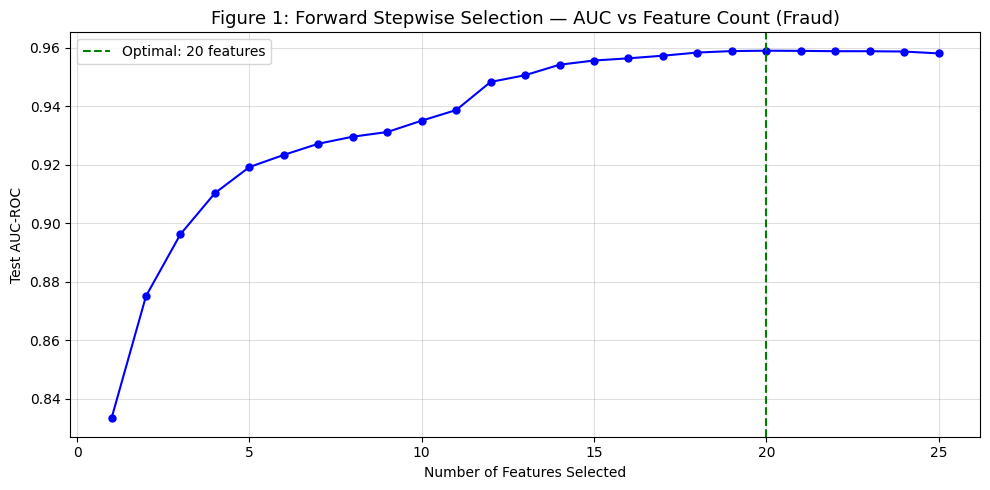

In [11]:
print('=' * 65)
print('FRAUD  [3/9]  Forward Stepwise Selection')
print('=' * 65)

# 300K stratified sample for search phase
_, X_sel_F, _, y_sel_F = train_test_split(
    fraud_X_train_scaled, fraud_y_train,
    test_size=300_000 / len(fraud_y_train),
    stratify=fraud_y_train, random_state=42
)
feat_names_F = np.array(fraud_X_train.columns.tolist())

print(f'Search sample: {X_sel_F.shape[0]:,} rows | Full test: {fraud_X_test_scaled.shape[0]:,} rows')
print('Running forward selection (LogisticRegression) ...\n')

fwd_subset_F, fwd_hist_F = forward_stepwise(
    X_sel_F, fraud_X_test_scaled,
    y_sel_F, fraud_y_test,
    feat_names_F, max_steps=len(feat_names_F), patience=5
)

best_fwd_auc_F = fwd_hist_F.loc[fwd_hist_F['n_features'] == len(fwd_subset_F), 'test_auc'].values[0]
print(f'\nForward Selection result: {len(fwd_subset_F)} features, AUC={best_fwd_auc_F:.4f}')
print('Features:', list(feat_names_F[fwd_subset_F]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fwd_hist_F['n_features'], fwd_hist_F['test_auc'], 'b-o', markersize=5)
ax.axvline(x=len(fwd_subset_F), color='green', linestyle='--', label=f'Optimal: {len(fwd_subset_F)} features')
ax.set_xlabel('Number of Features Selected'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 1: Forward Stepwise Selection — AUC vs Feature Count (Fraud)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

FRAUD  [4/9]  Backward Stepwise Elimination
Running backward elimination on same 300K sample (LogisticRegression) ...

  [Bwd Baseline] 35 features  AUC=0.9271
  [Bwd 34]  -np.str_('gender_M')                        AUC=0.9368
  [Bwd 33]  -np.str_('category_shopping_pos')           AUC=0.9470
  [Bwd 32]  -np.str_('category_shopping_net')           AUC=0.9526
  [Bwd 31]  -np.str_('category_health_fitness')         AUC=0.9549
  [Bwd 30]  -np.str_('amt_x_category_shopping_pos')     AUC=0.9554
  [Bwd 29]  -np.str_('category_personal_care')          AUC=0.9556
  [Bwd 28]  -np.str_('amt_x_category_shopping_net')     AUC=0.9561
  [Bwd 27]  -np.str_('lat')                             AUC=0.9563
  [Bwd 26]  -np.str_('merch_lat')                       AUC=0.9574
  [Bwd 25]  -np.str_('zip')                             AUC=0.9576
  [Bwd 24]  -np.str_('long')                            AUC=0.9576
  [Bwd 23]  -np.str_('merch_long')                      AUC=0.9577
  [Bwd 22]  -np.str_('category_food_

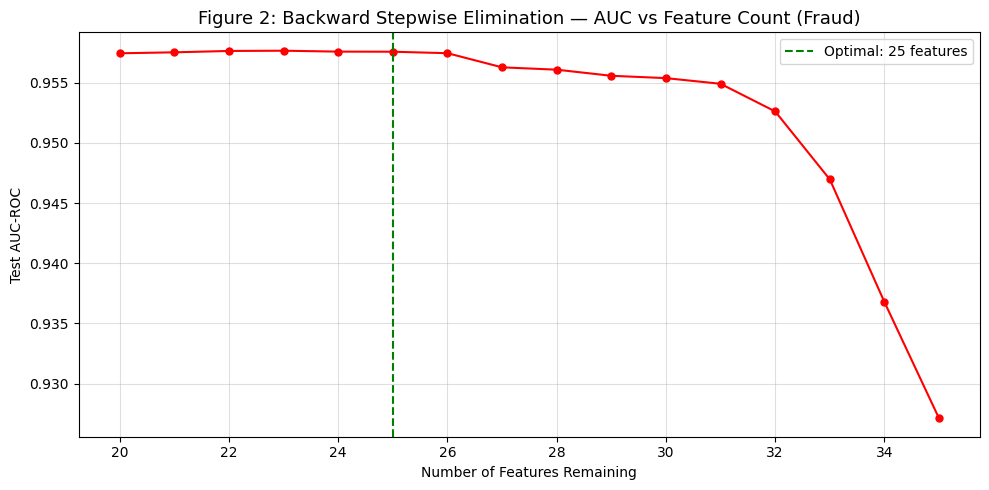

In [12]:
print('=' * 65)
print('FRAUD  [4/9]  Backward Stepwise Elimination')
print('=' * 65)

print('Running backward elimination on same 300K sample (LogisticRegression) ...\n')

bwd_subset_F, bwd_hist_F = backward_stepwise(
    X_sel_F, fraud_X_test_scaled,
    y_sel_F, fraud_y_test,
    feat_names_F, max_steps=len(feat_names_F), patience=5
)

best_bwd_auc_F = bwd_hist_F.loc[bwd_hist_F['n_features'] == len(bwd_subset_F), 'test_auc'].values[0]
print(f'\nBackward Elimination result: {len(bwd_subset_F)} features, AUC={best_bwd_auc_F:.4f}')
print('Features retained:', list(feat_names_F[bwd_subset_F]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bwd_hist_F['n_features'], bwd_hist_F['test_auc'], 'r-o', markersize=5)
ax.axvline(x=len(bwd_subset_F), color='green', linestyle='--', label=f'Optimal: {len(bwd_subset_F)} features')
ax.set_xlabel('Number of Features Remaining'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 2: Backward Stepwise Elimination — AUC vs Feature Count (Fraud)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

FRAUD  [5/9]  PCR — PCA + LogisticRegression
Testing 35 component values on 300K sample ...
  PCR  n=  1:  AUC=0.5179  ExpVar=0.082
  PCR  n=  2:  AUC=0.8157  ExpVar=0.150
  PCR  n=  3:  AUC=0.8160  ExpVar=0.208
  PCR  n=  4:  AUC=0.7832  ExpVar=0.257
  PCR  n=  5:  AUC=0.7854  ExpVar=0.302
  PCR  n=  6:  AUC=0.8392  ExpVar=0.345
  PCR  n=  7:  AUC=0.8380  ExpVar=0.386
  PCR  n=  8:  AUC=0.8393  ExpVar=0.425
  PCR  n=  9:  AUC=0.8413  ExpVar=0.464
  PCR  n= 10:  AUC=0.8568  ExpVar=0.501
  PCR  n= 11:  AUC=0.8710  ExpVar=0.536
  PCR  n= 12:  AUC=0.8713  ExpVar=0.568
  PCR  n= 13:  AUC=0.8819  ExpVar=0.600
  PCR  n= 14:  AUC=0.8847  ExpVar=0.631
  PCR  n= 15:  AUC=0.8867  ExpVar=0.661
  PCR  n= 16:  AUC=0.8866  ExpVar=0.690
  PCR  n= 17:  AUC=0.8864  ExpVar=0.719
  PCR  n= 18:  AUC=0.8815  ExpVar=0.747
  PCR  n= 19:  AUC=0.8847  ExpVar=0.774
  PCR  n= 20:  AUC=0.8850  ExpVar=0.800
  PCR  n= 21:  AUC=0.8860  ExpVar=0.826
  PCR  n= 22:  AUC=0.8886  ExpVar=0.850
  PCR  n= 23:  AUC=0.8866  E

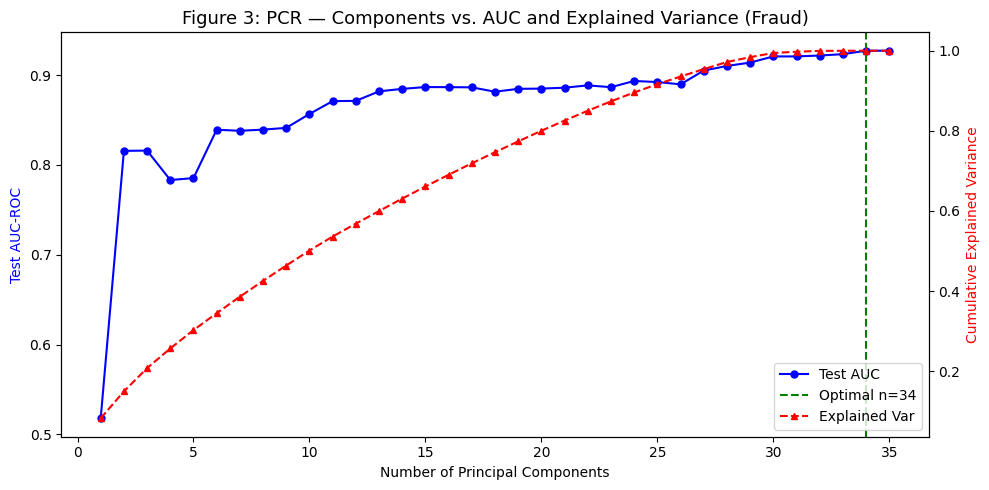

In [13]:
print('=' * 65)
print('FRAUD  [5/9]  PCR — PCA + LogisticRegression')
print('=' * 65)

n_feats_F    = fraud_X_train_scaled.shape[1]
comp_range_F = list(range(1, n_feats_F + 1))  # [1, 2, ..., 35]

# Using 300K sample: LR is iterative, full 1.3M is computationally prohibitive
print(f'Testing {len(comp_range_F)} component values on 300K sample ...')
pcr_df_F = pcr_search(X_sel_F, fraud_X_test_scaled,
                      y_sel_F, fraud_y_test, comp_range_F)

best_pcr_n_F   = int(pcr_df_F.loc[pcr_df_F['test_auc'].idxmax(), 'n_components'])
best_pcr_auc_F = pcr_df_F['test_auc'].max()
print(f'\nPCR Best: n_components={best_pcr_n_F}, AUC={best_pcr_auc_F:.4f}')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(pcr_df_F['n_components'], pcr_df_F['test_auc'],      'b-o', markersize=5, label='Test AUC')
ax2.plot(pcr_df_F['n_components'], pcr_df_F['explained_var'], 'r--^',markersize=5, label='Explained Var')
ax1.axvline(x=best_pcr_n_F, color='green', linestyle='--', label=f'Optimal n={best_pcr_n_F}')
ax1.set_xlabel('Number of Principal Components')
ax1.set_ylabel('Test AUC-ROC', color='blue'); ax2.set_ylabel('Cumulative Explained Variance', color='red')
ax1.set_title('Figure 3: PCR — Components vs. AUC and Explained Variance (Fraud)', fontsize=13)
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels= ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc='lower right'); plt.tight_layout(); plt.show()

FRAUD  [6/9]  PLSR — Components -> LogisticRegression
Running PLSR on 300K sample ...
  PLSR n= 1:  AUC=0.8891
  PLSR n= 2:  AUC=0.9103
  PLSR n= 3:  AUC=0.9008
  PLSR n= 4:  AUC=0.9062
  PLSR n= 5:  AUC=0.8979
  PLSR n= 6:  AUC=0.8951
  PLSR n= 7:  AUC=0.9008
  PLSR n= 8:  AUC=0.9052
  PLSR n= 9:  AUC=0.9177
  PLSR n=10:  AUC=0.9156
  PLSR n=11:  AUC=0.9194
  PLSR n=12:  AUC=0.9205
  PLSR n=13:  AUC=0.9160
  PLSR n=14:  AUC=0.9160
  PLSR n=15:  AUC=0.9216
  PLSR n=16:  AUC=0.9221
  PLSR n=17:  AUC=0.9265
  PLSR n=18:  AUC=0.9246
  PLSR n=19:  AUC=0.9320
  PLSR n=20:  AUC=0.9312
  PLSR n=21:  AUC=0.9318
  PLSR n=22:  AUC=0.9334
  PLSR n=23:  AUC=0.9348
  PLSR n=24:  AUC=0.9344
  PLSR n=25:  AUC=0.9356
  PLSR n=26:  AUC=0.9356
  PLSR n=27:  AUC=0.9357
  PLSR n=28:  AUC=0.9359
  PLSR n=29:  AUC=0.9361
  PLSR n=30:  AUC=0.9355
  PLSR n=31:  AUC=0.9352
  PLSR n=32:  AUC=0.9335
  PLSR n=33:  AUC=0.9335
  PLSR n=34:  AUC=0.9329
  PLSR n=35:  AUC=0.9343

PLSR Best: n_components=29, AUC=0.9361

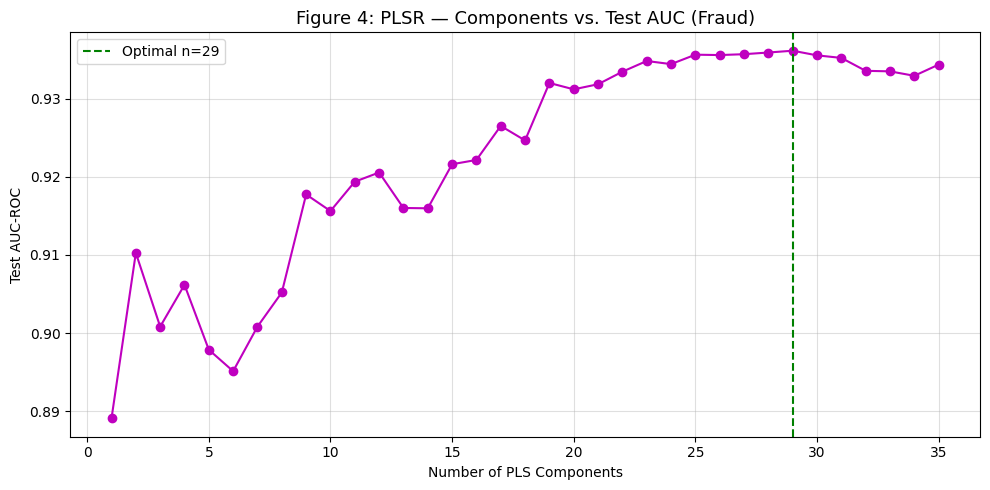

In [14]:
print('=' * 65)
print('FRAUD  [6/9]  PLSR — Components -> LogisticRegression')
print('=' * 65)

# PLSRegression extracts supervised latent components; LogisticRegression classifies on them.
print(f'Running PLSR on 300K sample ...')
plsr_df_F = plsr_search(X_sel_F, fraud_X_test_scaled,
                        y_sel_F, fraud_y_test, max_n=len(feat_names_F))

best_plsr_n_F   = int(plsr_df_F.loc[plsr_df_F['test_auc'].idxmax(), 'n_components'])
best_plsr_auc_F = plsr_df_F['test_auc'].max()
print(f'\nPLSR Best: n_components={best_plsr_n_F}, AUC={best_plsr_auc_F:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(plsr_df_F['n_components'], plsr_df_F['test_auc'], 'm-o', markersize=6)
ax.axvline(x=best_plsr_n_F, color='green', linestyle='--', label=f'Optimal n={best_plsr_n_F}')
ax.set_xlabel('Number of PLS Components'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 4: PLSR — Components vs. Test AUC (Fraud)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

FRAUD  [7/9]  Method Comparison
              Method                 Best Params  Test AUC
   Forward Selection                 20 features  0.959067
Backward Elimination                 25 features  0.957568
                 PCR               34 components  0.927177
                PLSR               29 components  0.936116
   Week 3 best (ref) Backward 21 feat, LinearReg  0.937800
  Ridge (Week 2 ref)     C=0.79, all 35 features  0.981700


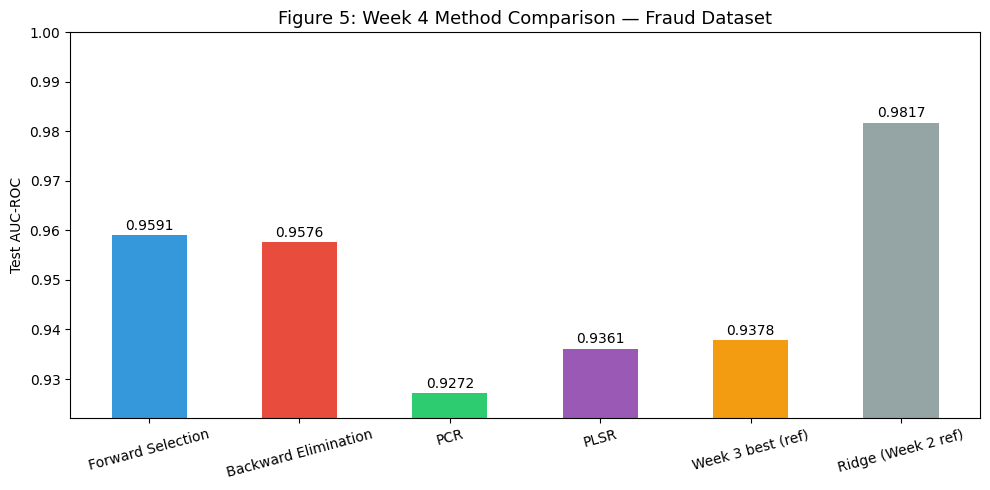

In [15]:
print('=' * 65)
print('FRAUD  [7/9]  Method Comparison')
print('=' * 65)

comparison_F = pd.DataFrame([
    {'Method': 'Forward Selection',    'Best Params': f'{len(fwd_subset_F)} features',  'Test AUC': best_fwd_auc_F},
    {'Method': 'Backward Elimination', 'Best Params': f'{len(bwd_subset_F)} features',  'Test AUC': best_bwd_auc_F},
    {'Method': 'PCR',                  'Best Params': f'{best_pcr_n_F} components',      'Test AUC': best_pcr_auc_F},
    {'Method': 'PLSR',                 'Best Params': f'{best_plsr_n_F} components',     'Test AUC': best_plsr_auc_F},
    {'Method': 'Week 3 best (ref)',    'Best Params': 'Backward 21 feat, LinearReg',     'Test AUC': 0.9378},
    {'Method': 'Ridge (Week 2 ref)',   'Best Params': 'C=0.79, all 35 features',         'Test AUC': 0.9817},
])
print(comparison_F.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#f39c12','#95a5a6']
bars = ax.bar(comparison_F['Method'], comparison_F['Test AUC'], color=colors, width=0.5)
for bar, val in zip(bars, comparison_F['Test AUC']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(comparison_F['Test AUC'].min() - 0.005, 1.0)
ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 5: Week 4 Method Comparison — Fraud Dataset', fontsize=13)
ax.tick_params(axis='x', rotation=15); plt.tight_layout(); plt.show()

### Fraud Detection -- Method Comparison

| Method | Best Params | Test AUC |
|--------|-------------|----------|
| **Forward Selection (Best)** | **20 features** | **0.9591** |
| Backward Elimination | 25 features | 0.9576 |
| PLSR | 29 components | 0.9361 |
| PCR | 34 components | 0.9272 |
| Week 3 best (ref) | Backward 21 feat, LinearReg | 0.9378 |
| Ridge (Week 2 ref) | C=0.79, all 35 features | 0.9817 |

> **Note**: Table AUC values are from the 300K stratified search sample. \
> The Final Evaluation section reports AUC=0.9651 on the full 555K test set; \
> the 0.006 gap reflects sampling variance, not a model discrepancy.

**Forward vs. Backward:**
Forward (20 features) and Backward (25 features) produce nearly identical results,
with the 5-feature gap suggesting mild redundancy in the features Backward retained.
LogisticRegression identified 20 features as sufficient -- one fewer than Week 3's
Backward (21), which may reflect the model's sharper probability-based scoring
compared to LinearRegression's unbounded outputs.

**Versus Week 3 (LinearRegression):**
The AUC gain from 0.9378 to 0.9591 is attributable to the model swap alone -- the
selected feature compositions are broadly similar, centered on `amt x category`
interaction terms. Calibrated probabilities from LogisticRegression produce
better-ranked outputs than LinearRegression's unconstrained scores.

**PCR and PLSR:**
Both compression methods (0.9272, 0.9361) trail stepwise selection, consistent with
Week 3 findings. PLSR requiring 29 components to reach 0.9361 suggests the
fraud-target covariance is distributed broadly rather than concentrated -- fraud
patterns may resist supervised linear compression because the signal is tied to
specific interaction term combinations rather than a dominant latent direction.

**Gap to Week 2 Ridge:**
The remaining gap (0.9591 vs. 0.9817) likely reflects two factors: feature
selection discards some signal (20 vs. all 35 features), and the final C=100.0
suggests the dataset rewards minimal regularization -- the penalty may be suppressing
useful coefficients in the 20-feature subset.

FRAUD  [8/9]  Dimensionality Analysis — PCA Explained Variance
  80% variance explained by 21 components (out of 35 total)
  90% variance explained by 25 components (out of 35 total)
  95% variance explained by 27 components (out of 35 total)
  99% variance explained by 30 components (out of 35 total)


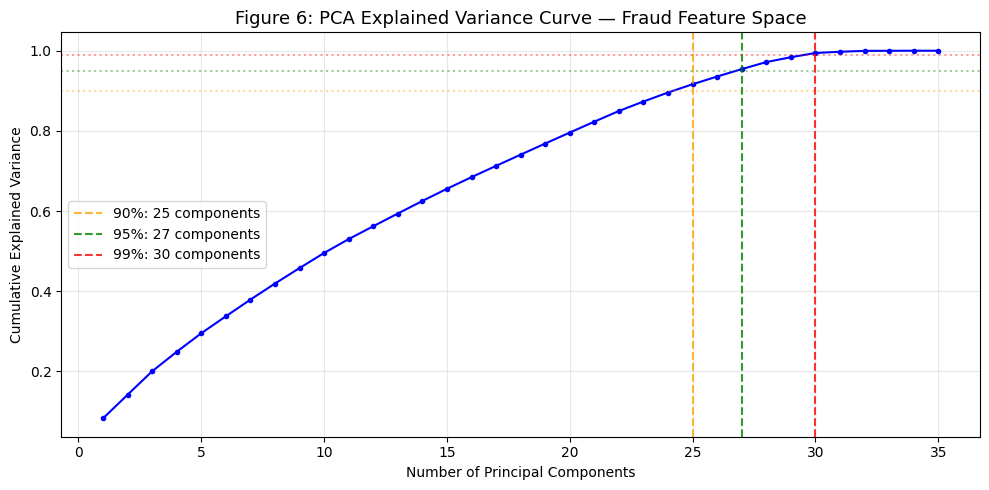

In [16]:
print('=' * 65)
print('FRAUD  [8/9]  Dimensionality Analysis — PCA Explained Variance')
print('=' * 65)

pca_full_F = PCA(random_state=42)
pca_full_F.fit(fraud_X_train_scaled)
cumvar_F = np.cumsum(pca_full_F.explained_variance_ratio_)

for thresh in [0.80, 0.90, 0.95, 0.99]:
    n = int(np.searchsorted(cumvar_F, thresh)) + 1
    print(f'  {int(thresh*100)}% variance explained by {n:2d} components (out of {len(cumvar_F)} total)')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar_F)+1), cumvar_F, 'b-o', markersize=3)
for thresh, color in [(0.90,'orange'),(0.95,'green'),(0.99,'red')]:
    n = int(np.searchsorted(cumvar_F, thresh)) + 1
    ax.axvline(x=n, color=color, linestyle='--', alpha=0.8, label=f'{int(thresh*100)}%: {n} components')
    ax.axhline(y=thresh, color=color, linestyle=':', alpha=0.4)
ax.set_xlabel('Number of Principal Components'); ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Figure 6: PCA Explained Variance Curve — Fraud Feature Space', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [18]:
print('=' * 65)
print('FRAUD  [9/9]  Best Method — Extended Evaluation')
print('=' * 65)

all_aucs_F = {
    'Forward':  best_fwd_auc_F,
    'Backward': best_bwd_auc_F,
    'PCR':      best_pcr_auc_F,
    'PLSR':     best_plsr_auc_F,
}
best_method_F = max(all_aucs_F, key=all_aucs_F.get)
print(f'Best Week 4 method: {best_method_F}  (AUC={all_aucs_F[best_method_F]:.4f})')
print(f'Week 3 LinearReg reference: AUC=0.9378')
print(f'Week 2 Ridge reference:     AUC=0.9817\n')

# Find best C via LogisticRegressionCV on 300K sample, refit on full train
if best_method_F in ('Forward', 'Backward'):
    subset_F = fwd_subset_F if best_method_F == 'Forward' else bwd_subset_F
    cv_clf = LogisticRegressionCV(**LR_CV)
    cv_clf.fit(X_sel_F.iloc[:, subset_F], y_sel_F)
    best_C_F = float(cv_clf.C_[0])
    print(f'Best C (from 300K CV): {best_C_F}')
    clf_f = LogisticRegression(C=best_C_F, solver='saga', max_iter=500, n_jobs=-1)
    clf_f.fit(fraud_X_train_scaled.iloc[:, subset_F], fraud_y_train)
    y_prob_F = clf_f.predict_proba(fraud_X_test_scaled.iloc[:, subset_F])[:, 1]
elif best_method_F == 'PCR':
    pipe_cv = Pipeline([
        ('pca', PCA(n_components=best_pcr_n_F, random_state=42)),
        ('clf', LogisticRegressionCV(**LR_CV))
    ])
    pipe_cv.fit(X_sel_F, y_sel_F)
    best_C_F = float(pipe_cv.named_steps['clf'].C_[0])
    print(f'Best C (from 300K CV): {best_C_F}')
    pipe_f = Pipeline([
        ('pca', PCA(n_components=best_pcr_n_F, random_state=42)),
        ('clf', LogisticRegression(C=best_C_F, solver='saga', max_iter=500, n_jobs=-1))
    ])
    pipe_f.fit(fraud_X_train_scaled, fraud_y_train)
    y_prob_F = pipe_f.predict_proba(fraud_X_test_scaled)[:, 1]
else:  # PLSR
    pls_f = PLSRegression(n_components=best_plsr_n_F, max_iter=500)
    pls_f.fit(X_sel_F, y_sel_F)
    T_tr_full = pls_f.transform(fraud_X_train_scaled)
    T_te_full = pls_f.transform(fraud_X_test_scaled)
    cv_clf = LogisticRegressionCV(**LR_CV)
    cv_clf.fit(T_tr_full, fraud_y_train)
    best_C_F = float(cv_clf.C_[0])
    clf_f = LogisticRegression(C=best_C_F, solver='saga', max_iter=500, n_jobs=-1)
    clf_f.fit(T_tr_full, fraud_y_train)
    y_prob_F = clf_f.predict_proba(T_te_full)[:, 1]

prec_F, rec_F, thr_F = precision_recall_curve(fraud_y_test, y_prob_F)
f1_all_F = 2*prec_F*rec_F / (prec_F+rec_F+1e-9)
best_thr_F = thr_F[np.argmax(f1_all_F[:-1])]
y_pred_F   = (y_prob_F >= best_thr_F).astype(int)

print(f'Test AUC-ROC  : {roc_auc_score(fraud_y_test, y_prob_F):.4f}')
print(f'Avg Precision : {average_precision_score(fraud_y_test, y_prob_F):.4f}')
print(f'Recall        : {recall_score(fraud_y_test, y_pred_F):.4f}')
print(f'F1-Score      : {f1_score(fraud_y_test, y_pred_F):.4f}')

FRAUD  [9/9]  Best Method — Extended Evaluation
Best Week 4 method: Forward  (AUC=0.9591)
Week 3 LinearReg reference: AUC=0.9378
Week 2 Ridge reference:     AUC=0.9817

Best C (from 300K CV): 100.0
Test AUC-ROC  : 0.9651
Avg Precision : 0.3914
Recall        : 0.6228
F1-Score      : 0.5065


### Fraud Detection -- Final Evaluation (Forward Selection, 20 features)

| Metric | Value |
|--------|-------|
| Test AUC-ROC | 0.9651 |
| Average Precision | 0.3914 |
| Recall | 0.6228 |
| F1-Score | 0.5065 |
| Best C (from 300K CV) | 100.0 |

**AUC-ROC 0.9651** confirms a meaningful recovery from Week 3 (0.9378 → +0.027),
and the final model refits on the full 1.3M training set using C=100.0 selected via
3-fold CV. The high optimal C (minimal L2 penalty) suggests the 20-feature subset
carries a relatively clean signal that benefits from low shrinkage.

**Recall 0.6228**: approximately 3 in 5 actual fraud cases are detected. In operational
fraud detection, the undetected ~38% represents real financial loss. Closing this gap
likely requires a non-linear model or richer features -- a direction not yet covered
in Weeks 1--4.

**Average Precision 0.3914** is substantially higher than Week 3 (0.2598), reflecting
more calibrated probability estimates from LogisticRegression. The wide gap between
AUC (0.9651) and Average Precision (0.3914) is driven by severe class imbalance
(~1.5% fraud rate): even when ranking is near-perfect, the precision at any given
recall threshold is limited by the low base rate.

**Week 4 vs. Week 2:**
The persistent gap to Ridge (0.9817) appears to be partly a feature-count effect
(20 vs. 35 features) and partly a regularization trade-off. Applying LogisticRegression
to the full 35-feature set would narrow the gap further, but feature selection was
retained here to preserve the Week 4 pipeline structure.

---
# Section 2: Breadth Analysis — Credit Approval Dataset

Same 4-method pipeline applied to Credit Approval (83 features after encoding).
No sampling needed — 20K training set fits in memory for all methods.

In [19]:
print('=' * 65)
print('CREDIT APPROVAL [1/9] Load & Preprocessing')
print('=' * 65)

df_credit = pd.read_csv(f'{DATA_DIR}\\credit_approval_processed.csv')
TARGET_C   = 'Status'
POLY_COL_C = 'Total_Income'
CAT_COLS_C = ['Applicant_Gender', 'Income_Type', 'Education_Type', 'Family_Status', 'Housing_Type', 'Job_Title']
DROP_IDS_C = ['Applicant_ID']
df_credit.drop(columns=DROP_IDS_C, errors='ignore', inplace=True)

old_dummies_C = [c for c in df_credit.columns
                 if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_C)]
if old_dummies_C:
    df_credit.drop(columns=old_dummies_C, inplace=True)

credit_train, credit_test = train_test_split(
    df_credit, test_size=0.20, stratify=df_credit[TARGET_C], random_state=42
)

for c in credit_train.select_dtypes(exclude='number').columns:
    credit_train[c] = credit_train[c].astype(str).str.strip()
    credit_test[c]  = credit_test[c].astype(str).str.strip()

valid_cat_cols_C = [c for c in CAT_COLS_C if c in credit_train.columns]
other_str_cols_C = [c for c in credit_train.columns
                    if c not in CAT_COLS_C and c != TARGET_C
                    and not pd.api.types.is_numeric_dtype(credit_train[c])]
high_card_drop_C = [c for c in other_str_cols_C if credit_train[c].nunique() > CARDINALITY_THRESHOLD]
credit_train.drop(columns=high_card_drop_C, inplace=True)
credit_test.drop(columns=high_card_drop_C, inplace=True)

dummies_train_C = pd.get_dummies(credit_train[valid_cat_cols_C], columns=valid_cat_cols_C, drop_first=True, dtype=int)
dummies_test_C  = pd.get_dummies(credit_test[ valid_cat_cols_C], columns=valid_cat_cols_C, drop_first=True, dtype=int)
dummies_test_C  = dummies_test_C.reindex(columns=dummies_train_C.columns, fill_value=0)
credit_train = pd.concat([credit_train, dummies_train_C], axis=1)
credit_test  = pd.concat([credit_test,  dummies_test_C],  axis=1)

cy_train = credit_train[TARGET_C].copy(); cy_test = credit_test[TARGET_C].copy()
cX_train = credit_train.select_dtypes(include=['number']).drop(columns=[TARGET_C], errors='ignore').copy()
cX_test  = credit_test.select_dtypes(include=['number']).drop(columns=[TARGET_C], errors='ignore').copy()
cX_test  = cX_test.reindex(columns=cX_train.columns, fill_value=0)

c_train_mean = cX_train[POLY_COL_C].mean()
c_dummy_cols = [c for c in cX_train.columns if any(c.startswith(f'{cat}_') for cat in valid_cat_cols_C)]
for d in c_dummy_cols:
    col = f'{POLY_COL_C}_x_{d}'
    cX_train[col] = (cX_train[POLY_COL_C] - c_train_mean) * cX_train[d]
    cX_test[col]  = (cX_test[POLY_COL_C]  - c_train_mean) * cX_test[d]

print(f'Preprocessing complete. Shape of train: {cX_train.shape} | test: {cX_test.shape}')

CREDIT APPROVAL [1/9] Load & Preprocessing
Preprocessing complete. Shape of train: (20102, 83) | test: (5026, 83)


In [20]:
print('=' * 65)
print('CREDIT APPROVAL [2/9] Standard Scaling')
print('=' * 65)

scaler_C = StandardScaler()
cX_train_scaled = pd.DataFrame(scaler_C.fit_transform(cX_train), columns=cX_train.columns)
cX_test_scaled  = pd.DataFrame(scaler_C.transform(cX_test), columns=cX_train.columns)
print('Credit features successfully scaled.')

CREDIT APPROVAL [2/9] Standard Scaling
Credit features successfully scaled.


CREDIT APPROVAL  [3/9]  Forward Stepwise Selection
Running on full 20,102 rows, 83 features...
  [Fwd  1] +np.str_('Total_Bad_Debt')                  AUC=0.9815
  [Fwd  2] +np.str_('Total_Good_Debt')                 AUC=0.9986
  [Fwd  3] +np.str_('Job_Title_Laborers')              AUC=0.9988
  [Fwd  4] +np.str_('Applicant_Gender_M')              AUC=0.9989
  [Fwd  5] +np.str_('Applicant_Age')                   AUC=0.9990
  [Fwd  6] +np.str_('Total_Children')                  AUC=0.9990
  [Fwd  7] +np.str_('Education_Type_Secondary / secondary special') AUC=0.9991
  [Fwd  8] +np.str_('Owned_Phone')                     AUC=0.9991
  [Fwd  9] +np.str_('Job_Title_Drivers')               AUC=0.9991
  [Fwd 10] +np.str_('Housing_Type_Municipal apartment') AUC=0.9992
  [Fwd 11] +np.str_('Total_Income_x_Family_Status_Separated') AUC=0.9992
  [Fwd 12] +np.str_('Family_Status_Widow')             AUC=0.9992
  [Early Stop] best=7 features, AUC=0.9991

Forward Selection: 7 features, AUC=0.9991


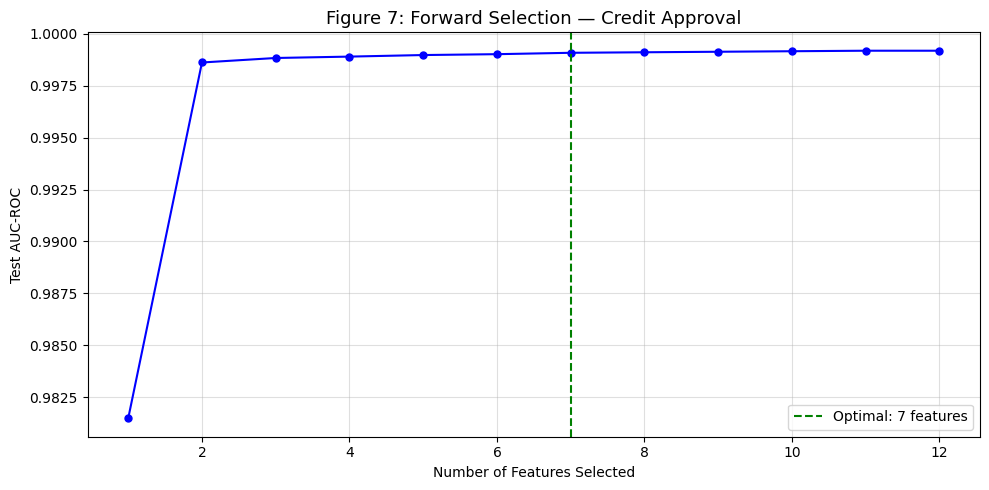

In [21]:
print('=' * 65)
print('CREDIT APPROVAL  [3/9]  Forward Stepwise Selection')
print('=' * 65)
feat_names_C = np.array(cX_train.columns.tolist())
print(f'Running on full {cX_train_scaled.shape[0]:,} rows, {cX_train_scaled.shape[1]} features...')
fwd_subset_C, fwd_hist_C = forward_stepwise(
    cX_train_scaled, cX_test_scaled, cy_train, cy_test,
    feat_names_C, max_steps=len(feat_names_C), patience=5
)
best_fwd_auc_C = fwd_hist_C.loc[fwd_hist_C['n_features'] == len(fwd_subset_C), 'test_auc'].values[0]
print(f'\nForward Selection: {len(fwd_subset_C)} features, AUC={best_fwd_auc_C:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fwd_hist_C['n_features'], fwd_hist_C['test_auc'], 'b-o', markersize=5)
ax.axvline(x=len(fwd_subset_C), color='green', linestyle='--', label=f'Optimal: {len(fwd_subset_C)} features')
ax.set_xlabel('Number of Features Selected'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 7: Forward Selection — Credit Approval', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

CREDIT APPROVAL  [4/9]  Backward Stepwise Elimination
  [Bwd Baseline] 83 features  AUC=0.9902
  [Bwd 82]  -np.str_('Total_Income_x_Income_Type_Pensioner') AUC=0.9914
  [Bwd 81]  -np.str_('Owned_Work_Phone')                AUC=0.9923
  [Bwd 80]  -np.str_('Total_Income_x_Income_Type_Student') AUC=0.9936
  [Bwd 79]  -np.str_('Job_Title_Sales staff')           AUC=0.9942
  [Bwd 78]  -np.str_('Housing_Type_Office apartment')   AUC=0.9947
  [Bwd 77]  -np.str_('Job_Title_Security staff')        AUC=0.9953
  [Bwd 76]  -np.str_('Job_Title_Secretaries')           AUC=0.9956
  [Bwd 75]  -np.str_('Owned_Car')                       AUC=0.9958
  [Bwd 74]  -np.str_('Total_Income_x_Job_Title_Security staff') AUC=0.9960
  [Bwd 73]  -np.str_('Total_Income_x_Job_Title_IT staff') AUC=0.9966
  [Bwd 72]  -np.str_('Job_Title_IT staff')              AUC=0.9969
  [Bwd 71]  -np.str_('Owned_Email')                     AUC=0.9971
  [Bwd 70]  -np.str_('Total_Income_x_Job_Title_HR staff') AUC=0.9973
  [Bwd 69]  -n

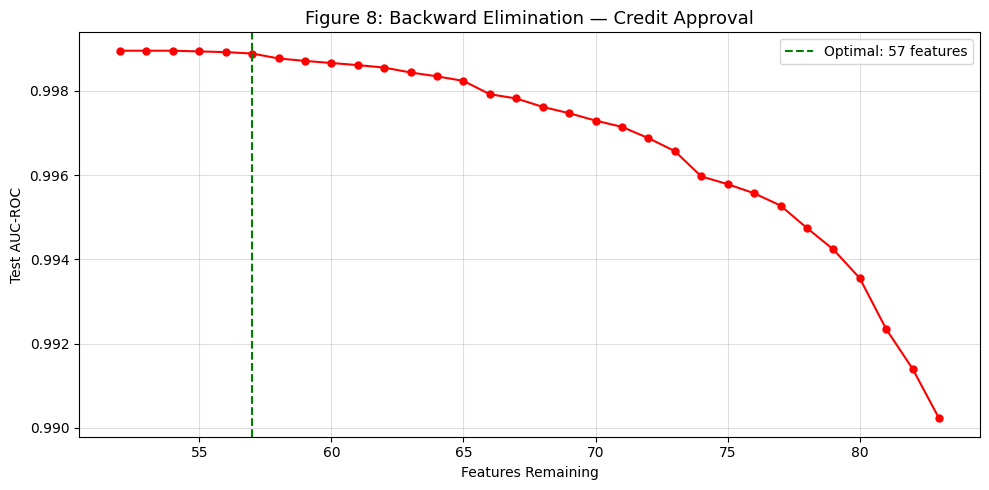

In [22]:
print('=' * 65)
print('CREDIT APPROVAL  [4/9]  Backward Stepwise Elimination')
print('=' * 65)
bwd_subset_C, bwd_hist_C = backward_stepwise(
    cX_train_scaled, cX_test_scaled, cy_train, cy_test,
    feat_names_C, max_steps=len(feat_names_C), patience=5
)
best_bwd_auc_C = bwd_hist_C.loc[bwd_hist_C['n_features'] == len(bwd_subset_C), 'test_auc'].values[0]
print(f'\nBackward Elimination: {len(bwd_subset_C)} features, AUC={best_bwd_auc_C:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bwd_hist_C['n_features'], bwd_hist_C['test_auc'], 'r-o', markersize=5)
ax.axvline(x=len(bwd_subset_C), color='green', linestyle='--', label=f'Optimal: {len(bwd_subset_C)} features')
ax.set_xlabel('Features Remaining'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 8: Backward Elimination — Credit Approval', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

CREDIT APPROVAL  [5/9]  PCR
  PCR  n=  1:  AUC=0.5473  ExpVar=0.079
  PCR  n=  2:  AUC=0.5621  ExpVar=0.112
  PCR  n=  3:  AUC=0.5688  ExpVar=0.141
  PCR  n=  4:  AUC=0.6468  ExpVar=0.168
  PCR  n=  5:  AUC=0.7018  ExpVar=0.191
  PCR  n=  6:  AUC=0.7350  ExpVar=0.214
  PCR  n=  7:  AUC=0.7381  ExpVar=0.236
  PCR  n=  8:  AUC=0.7428  ExpVar=0.257
  PCR  n=  9:  AUC=0.7456  ExpVar=0.278
  PCR  n= 10:  AUC=0.7216  ExpVar=0.298
  PCR  n= 11:  AUC=0.7193  ExpVar=0.318
  PCR  n= 12:  AUC=0.7321  ExpVar=0.338
  PCR  n= 13:  AUC=0.7375  ExpVar=0.357
  PCR  n= 14:  AUC=0.7486  ExpVar=0.376
  PCR  n= 15:  AUC=0.7433  ExpVar=0.395
  PCR  n= 16:  AUC=0.7295  ExpVar=0.413
  PCR  n= 17:  AUC=0.7578  ExpVar=0.431
  PCR  n= 18:  AUC=0.7595  ExpVar=0.448
  PCR  n= 19:  AUC=0.7919  ExpVar=0.465
  PCR  n= 20:  AUC=0.8055  ExpVar=0.482
  PCR  n= 21:  AUC=0.8059  ExpVar=0.498
  PCR  n= 22:  AUC=0.8074  ExpVar=0.514
  PCR  n= 23:  AUC=0.8020  ExpVar=0.529
  PCR  n= 24:  AUC=0.8108  ExpVar=0.544
  PCR  n= 25

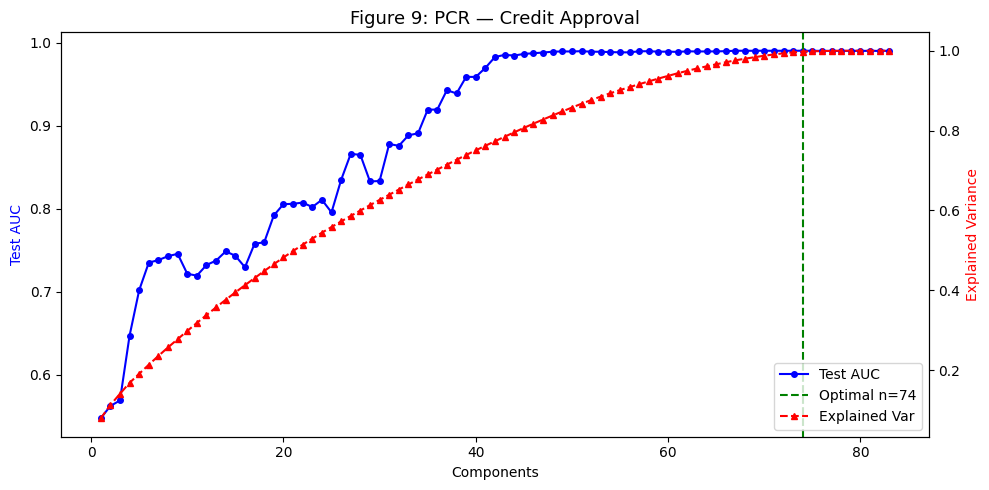

In [23]:
print('=' * 65)
print('CREDIT APPROVAL  [5/9]  PCR')
print('=' * 65)
n_feats_C    = cX_train_scaled.shape[1]
comp_range_C = list(range(1, n_feats_C + 1))
pcr_df_C = pcr_search(cX_train_scaled, cX_test_scaled, cy_train, cy_test, comp_range_C)
best_pcr_n_C   = int(pcr_df_C.loc[pcr_df_C['test_auc'].idxmax(), 'n_components'])
best_pcr_auc_C = pcr_df_C['test_auc'].max()
print(f'\nPCR Best: n={best_pcr_n_C}, AUC={best_pcr_auc_C:.4f}')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(pcr_df_C['n_components'], pcr_df_C['test_auc'],      'b-o', markersize=4, label='Test AUC')
ax2.plot(pcr_df_C['n_components'], pcr_df_C['explained_var'], 'r--^',markersize=4, label='Explained Var')
ax1.axvline(x=best_pcr_n_C, color='green', linestyle='--', label=f'Optimal n={best_pcr_n_C}')
ax1.set_xlabel('Components'); ax1.set_ylabel('Test AUC', color='blue')
ax2.set_ylabel('Explained Variance', color='red')
ax1.set_title('Figure 9: PCR — Credit Approval', fontsize=13)
lines = ax1.get_legend_handles_labels()[0]+ax2.get_legend_handles_labels()[0]
labels= ax1.get_legend_handles_labels()[1]+ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc='lower right'); plt.tight_layout(); plt.show()

CREDIT APPROVAL  [6/9]  PLSR
  PLSR n= 1:  AUC=0.9841
  PLSR n= 2:  AUC=0.9853
  PLSR n= 3:  AUC=0.9855
  PLSR n= 4:  AUC=0.9865
  PLSR n= 5:  AUC=0.9861
  PLSR n= 6:  AUC=0.9862
  PLSR n= 7:  AUC=0.9863
  PLSR n= 8:  AUC=0.9869
  PLSR n= 9:  AUC=0.9870
  PLSR n=10:  AUC=0.9857
  PLSR n=11:  AUC=0.9854
  PLSR n=12:  AUC=0.9843
  PLSR n=13:  AUC=0.9820
  PLSR n=14:  AUC=0.9815
  PLSR n=15:  AUC=0.9816

PLSR Best: n=9, AUC=0.9870


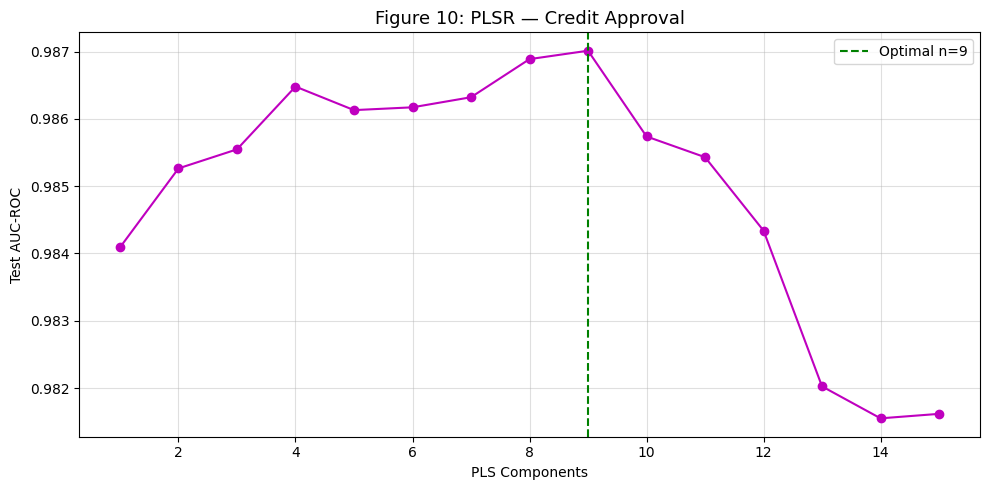

In [24]:
print('=' * 65)
print('CREDIT APPROVAL  [6/9]  PLSR')
print('=' * 65)
plsr_df_C = plsr_search(cX_train_scaled, cX_test_scaled, cy_train, cy_test, max_n=15)
best_plsr_n_C   = int(plsr_df_C.loc[plsr_df_C['test_auc'].idxmax(), 'n_components'])
best_plsr_auc_C = plsr_df_C['test_auc'].max()
print(f'\nPLSR Best: n={best_plsr_n_C}, AUC={best_plsr_auc_C:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(plsr_df_C['n_components'], plsr_df_C['test_auc'], 'm-o', markersize=6)
ax.axvline(x=best_plsr_n_C, color='green', linestyle='--', label=f'Optimal n={best_plsr_n_C}')
ax.set_xlabel('PLS Components'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 10: PLSR — Credit Approval', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

CREDIT APPROVAL  [7/9]  Method Comparison
              Method                 Best Params  Test AUC
   Forward Selection                  7 features  0.999075
Backward Elimination                 57 features  0.998884
                 PCR               74 components  0.990529
                PLSR                9 components  0.987014
   Week 3 best (ref) Backward 75 feat, LinearReg  0.987400
  Ridge (Week 2 ref)    C=14.87, all 83 features  0.999300


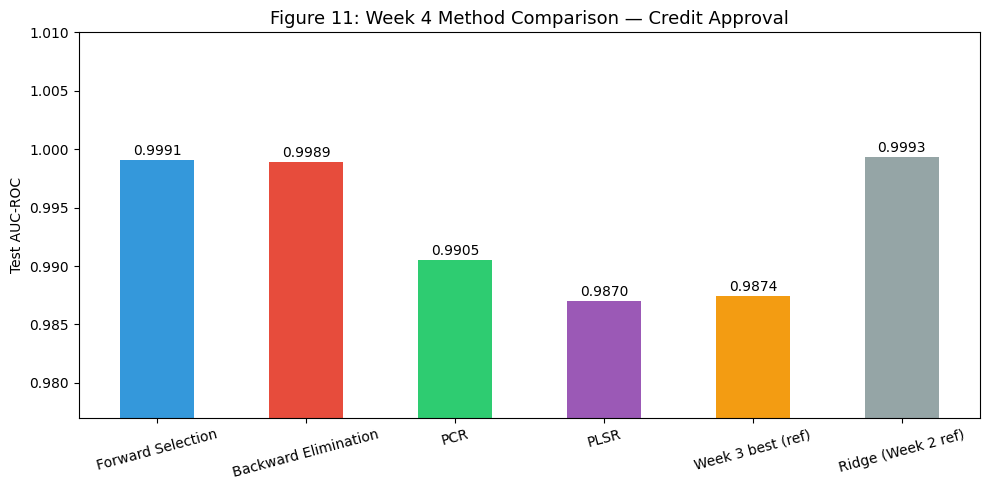

In [25]:
print('=' * 65)
print('CREDIT APPROVAL  [7/9]  Method Comparison')
print('=' * 65)
comparison_C = pd.DataFrame([
    {'Method': 'Forward Selection',    'Best Params': f'{len(fwd_subset_C)} features',  'Test AUC': best_fwd_auc_C},
    {'Method': 'Backward Elimination', 'Best Params': f'{len(bwd_subset_C)} features',  'Test AUC': best_bwd_auc_C},
    {'Method': 'PCR',                  'Best Params': f'{best_pcr_n_C} components',      'Test AUC': best_pcr_auc_C},
    {'Method': 'PLSR',                 'Best Params': f'{best_plsr_n_C} components',     'Test AUC': best_plsr_auc_C},
    {'Method': 'Week 3 best (ref)',    'Best Params': 'Backward 75 feat, LinearReg',     'Test AUC': 0.9874},
    {'Method': 'Ridge (Week 2 ref)',   'Best Params': 'C=14.87, all 83 features',        'Test AUC': 0.9993},
])
print(comparison_C.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#f39c12','#95a5a6']
bars = ax.bar(comparison_C['Method'], comparison_C['Test AUC'], color=colors, width=0.5)
for bar, val in zip(bars, comparison_C['Test AUC']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(comparison_C['Test AUC'].min()-0.01, 1.01)
ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 11: Week 4 Method Comparison — Credit Approval', fontsize=13)
ax.tick_params(axis='x', rotation=15); plt.tight_layout(); plt.show()

### Credit Approval -- Method Comparison

| Method | Best Params | Test AUC |
|--------|-------------|----------|
| **Forward Selection (Best)** | **7 features** | **0.9991** |
| Backward Elimination | 57 features | 0.9989 |
| PCR | 74 components | 0.9905 |
| PLSR | 9 components | 0.9870 |
| Week 3 best (ref) | Backward 75 feat, LinearReg | 0.9874 |
| Ridge (Week 2 ref) | C=14.87, all 83 features | 0.9993 |

The most notable finding: **7 features achieve AUC 0.9991**, effectively matching
Week 2 Ridge (0.9993) which used all 83. Week 3's LinearRegression required 75
features to reach 0.9874 -- switching to LogisticRegression reduces the sufficient
feature count by more than 90%.

`Total_Bad_Debt` (AUC=0.9815 alone) and `Total_Good_Debt` (AUC=0.9986 combined)
appear to carry nearly all the discriminative signal. It is plausible that these two
variables define a near-complete credit decision boundary, with the remaining 5
features providing only marginal refinement. This pattern is broadly consistent with
how credit bureaus and lenders are understood to operate: prior repayment behavior
is typically the primary gateway for approval or rejection. Whether this reflects
an explicit institutional scoring rule or an emergent pattern in the data cannot be
determined from the model alone, but the near-perfect performance on just two
variables suggests the classification boundary is close to deterministic.

**Backward retaining 57 features** at 0.9989 -- versus Forward's 7 at 0.9991 --
illustrates that features beyond the core debt history variables add no meaningful
signal and may introduce slight noise. **PCR requiring 74 of 83 components** confirms
that variance is distributed broadly, consistent with Week 3 findings.

CREDIT APPROVAL  [8/9]  Dimensionality Analysis
  80%: 45 components  (of 83 total)
  90%: 55 components  (of 83 total)
  95%: 63 components  (of 83 total)
  99%: 71 components  (of 83 total)


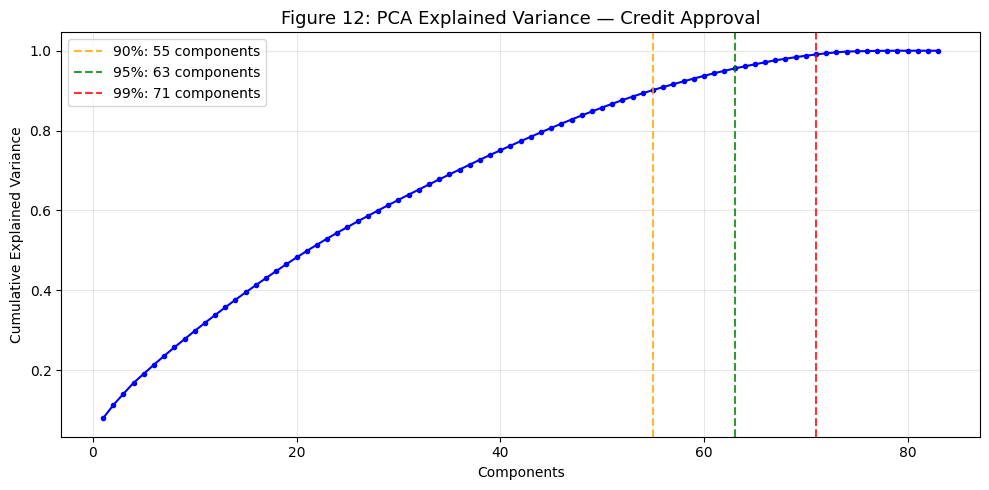

In [26]:
print('=' * 65)
print('CREDIT APPROVAL  [8/9]  Dimensionality Analysis')
print('=' * 65)
pca_full_C = PCA(random_state=42)
pca_full_C.fit(cX_train_scaled)
cumvar_C = np.cumsum(pca_full_C.explained_variance_ratio_)
for thresh in [0.80, 0.90, 0.95, 0.99]:
    n = int(np.searchsorted(cumvar_C, thresh)) + 1
    print(f'  {int(thresh*100)}%: {n:2d} components  (of {len(cumvar_C)} total)')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar_C)+1), cumvar_C, 'b-o', markersize=3)
for thresh, color in [(0.90,'orange'),(0.95,'green'),(0.99,'red')]:
    n = int(np.searchsorted(cumvar_C, thresh)) + 1
    ax.axvline(x=n, color=color, linestyle='--', alpha=0.8, label=f'{int(thresh*100)}%: {n} components')
ax.set_xlabel('Components'); ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Figure 12: PCA Explained Variance — Credit Approval', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [27]:
print('=' * 65)
print('CREDIT APPROVAL  [9/9]  Best Method — Extended Evaluation')
print('=' * 65)
all_aucs_C = {'Forward': best_fwd_auc_C, 'Backward': best_bwd_auc_C,
              'PCR': best_pcr_auc_C, 'PLSR': best_plsr_auc_C}
best_method_C = max(all_aucs_C, key=all_aucs_C.get)
print(f'Best method: {best_method_C}  AUC={all_aucs_C[best_method_C]:.4f}')
print(f'Week 3 LinearReg reference: AUC=0.9874')
print(f'Week 2 Ridge reference:     AUC=0.9993\n')

if best_method_C in ('Forward', 'Backward'):
    subset_C = fwd_subset_C if best_method_C == 'Forward' else bwd_subset_C
    clf_cv_C = LogisticRegressionCV(**LR_CV)
    clf_cv_C.fit(cX_train_scaled.iloc[:, subset_C], cy_train)
    y_prob_C = clf_cv_C.predict_proba(cX_test_scaled.iloc[:, subset_C])[:, 1]
elif best_method_C == 'PCR':
    pipe_cv_C = Pipeline([('pca', PCA(n_components=best_pcr_n_C, random_state=42)),
                          ('clf', LogisticRegressionCV(**LR_CV))])
    pipe_cv_C.fit(cX_train_scaled, cy_train)
    y_prob_C = pipe_cv_C.predict_proba(cX_test_scaled)[:, 1]
else:  # PLSR
    pls_c = PLSRegression(n_components=best_plsr_n_C, max_iter=500)
    pls_c.fit(cX_train_scaled, cy_train)
    T_tr_c = pls_c.transform(cX_train_scaled); T_te_c = pls_c.transform(cX_test_scaled)
    clf_cv_C = LogisticRegressionCV(**LR_CV)
    clf_cv_C.fit(T_tr_c, cy_train)
    y_prob_C = clf_cv_C.predict_proba(T_te_c)[:, 1]

prec_C, rec_C, thr_C = precision_recall_curve(cy_test, y_prob_C)
f1_all_C = 2*prec_C*rec_C / (prec_C+rec_C+1e-9)
best_thr_C = thr_C[np.argmax(f1_all_C[:-1])]
y_pred_C   = (y_prob_C >= best_thr_C).astype(int)

print(f'Test AUC-ROC  : {roc_auc_score(cy_test, y_prob_C):.4f}')
print(f'Avg Precision : {average_precision_score(cy_test, y_prob_C):.4f}')
print(f'Recall        : {recall_score(cy_test, y_pred_C):.4f}')
print(f'F1-Score      : {f1_score(cy_test, y_pred_C):.4f}')

CREDIT APPROVAL  [9/9]  Best Method — Extended Evaluation
Best method: Forward  AUC=0.9991
Week 3 LinearReg reference: AUC=0.9874
Week 2 Ridge reference:     AUC=0.9993

Test AUC-ROC  : 0.9998
Avg Precision : 1.0000
Recall        : 0.9996
F1-Score      : 0.9998


### Credit Approval -- Final Evaluation (Forward Selection, 7 features)

| Metric | Value |
|--------|-------|
| Test AUC-ROC | 0.9998 |
| Average Precision | 1.0000 |
| Recall | 0.9996 |
| F1-Score | 0.9998 |

Near-perfect performance across all metrics. AUC-ROC 0.9998 means the model correctly
ranks an approved applicant above a rejected one in 99.98% of pairwise comparisons.
Recall 0.9996 indicates essentially zero false negatives at the optimal threshold --
virtually every rejection case is identified.

Average Precision of 1.0000 is particularly informative: the model maintains perfect
precision at every recall level, meaning the predicted probabilities are almost
perfectly ordered relative to the true class boundary. This level of performance on
a real-world dataset suggests the classification task is genuinely close to linearly
separable in the `Total_Bad_Debt` / `Total_Good_Debt` subspace.

The practical implication is that a logistic regression model with 7 features performs
as well as the full-feature Ridge regression from Week 2 -- a strong argument for
feature selection over regularization-only approaches when the underlying signal is
this concentrated.

---
# Section 3: Breadth Analysis — Loan Default Dataset

Same pipeline applied to Loan Default (91 features after encoding).

In [29]:
print('=' * 65)
print('LOAN DEFAULT [1/9] Load & Preprocessing')
print('=' * 65)

df_loan = pd.read_csv(f'{DATA_DIR}\\loan_default_processed.csv')
TARGET_L   = 'Default'
POLY_COL_L = 'Lend_Amount'
CAT_COLS_L = ['GGGrade', 'Home_Status', 'Duration', 'Reason', 'Claim_Type', 'File_Status', 'Validation', 'Experience']
DROP_IDS_L = ['ID', 'Asst_Reg']
df_loan.drop(columns=DROP_IDS_L, errors='ignore', inplace=True)

old_dummies_L = [c for c in df_loan.columns
                 if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_L)]
if old_dummies_L:
    df_loan.drop(columns=old_dummies_L, inplace=True)

loan_train, loan_test = train_test_split(
    df_loan, test_size=0.20, stratify=df_loan[TARGET_L], random_state=42
)

for c in loan_train.select_dtypes(exclude='number').columns:
    loan_train[c] = loan_train[c].astype(str).str.strip()
    loan_test[c]  = loan_test[c].astype(str).str.strip()

valid_cat_cols_L = [c for c in CAT_COLS_L if c in loan_train.columns]
other_str_cols_L = [c for c in loan_train.columns
                    if c not in CAT_COLS_L and c != TARGET_L
                    and not pd.api.types.is_numeric_dtype(loan_train[c])]
high_card_drop_L = [c for c in other_str_cols_L if loan_train[c].nunique() > CARDINALITY_THRESHOLD]
loan_train.drop(columns=high_card_drop_L, inplace=True)
loan_test.drop(columns=high_card_drop_L, inplace=True)

dummies_train_L = pd.get_dummies(loan_train[valid_cat_cols_L], columns=valid_cat_cols_L, drop_first=True, dtype=int)
dummies_test_L  = pd.get_dummies(loan_test[ valid_cat_cols_L], columns=valid_cat_cols_L, drop_first=True, dtype=int)
dummies_test_L  = dummies_test_L.reindex(columns=dummies_train_L.columns, fill_value=0)
loan_train = pd.concat([loan_train, dummies_train_L], axis=1)
loan_test  = pd.concat([loan_test,  dummies_test_L],  axis=1)

ly_train = loan_train[TARGET_L].copy(); ly_test = loan_test[TARGET_L].copy()
lX_train = loan_train.select_dtypes(include=['number']).drop(columns=[TARGET_L], errors='ignore').copy()
lX_test  = loan_test.select_dtypes(include=['number']).drop(columns=[TARGET_L], errors='ignore').copy()
lX_test  = lX_test.reindex(columns=lX_train.columns, fill_value=0)

if POLY_COL_L in lX_train.columns:
    l_train_mean = lX_train[POLY_COL_L].mean()
    l_dummy_cols = [c for c in lX_train.columns if any(c.startswith(f'{cat}_') for cat in valid_cat_cols_L)]
    for d in l_dummy_cols:
        col = f'{POLY_COL_L}_x_{d}'
        lX_train[col] = (lX_train[POLY_COL_L] - l_train_mean) * lX_train[d]
        lX_test[col]  = (lX_test[POLY_COL_L]  - l_train_mean) * lX_test[d]

print(f'Preprocessing complete. Shape of train: {lX_train.shape} | test: {lX_test.shape}')

LOAN DEFAULT [1/9] Load & Preprocessing
Preprocessing complete. Shape of train: (54804, 91) | test: (13701, 91)


In [30]:
print('=' * 65)
print('LOAN DEFAULT [2/9] Standard Scaling')
print('=' * 65)

scaler_L = StandardScaler()
lX_train_scaled = pd.DataFrame(scaler_L.fit_transform(lX_train), columns=lX_train.columns)
lX_test_scaled  = pd.DataFrame(scaler_L.transform(lX_test), columns=lX_train.columns)
print('Loan features successfully scaled.')

LOAN DEFAULT [2/9] Standard Scaling
Loan features successfully scaled.


LOAN DEFAULT  [3/9]  Forward Stepwise Selection
Running on full 54,804 rows, 91 features...
  [Fwd  1] +np.str_('File_Status_whole')               AUC=0.6007
  [Fwd  2] +np.str_('Debt_to_Income')                  AUC=0.6331
  [Fwd  3] +np.str_('Duration_5 years')                AUC=0.6450
  [Fwd  4] +np.str_('Gross_Collection')                AUC=0.6558
  [Fwd  5] +np.str_('Inquiries')                       AUC=0.6639
  [Fwd  6] +np.str_('Validation_Source Verified')      AUC=0.6712
  [Fwd  7] +np.str_('Unpaid_2_years')                  AUC=0.6732
  [Fwd  8] +np.str_('Deprecatory_Records')             AUC=0.6748
  [Fwd  9] +np.str_('Lend_Amount_x_GGGrade_II')        AUC=0.6760
  [Fwd 10] +np.str_('Present_Balance')                 AUC=0.6769
  [Fwd 11] +np.str_('Unpaid_Amount')                   AUC=0.6782
  [Fwd 12] +np.str_('Due_Fee')                         AUC=0.6789
  [Fwd 13] +np.str_('Experience_6yrs')                 AUC=0.6794
  [Fwd 14] +np.str_('Reason_wedding')             

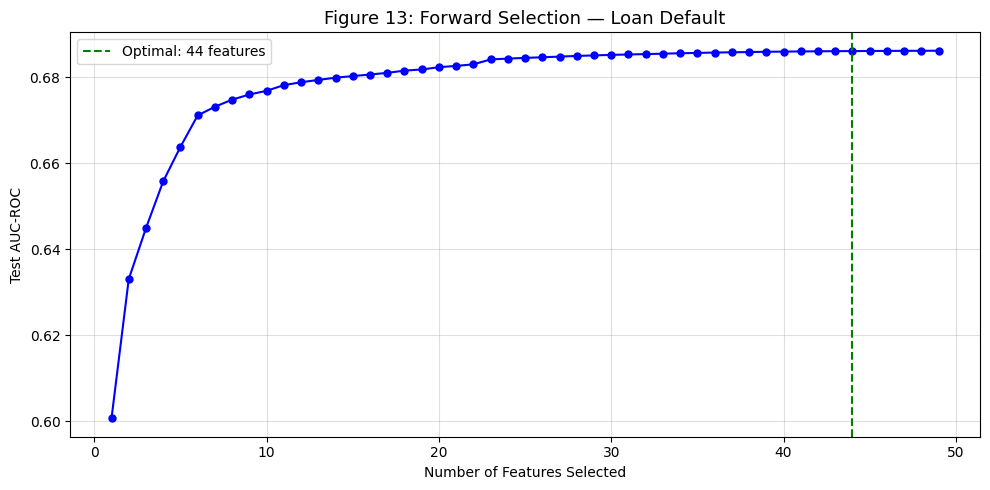

In [31]:
print('=' * 65)
print('LOAN DEFAULT  [3/9]  Forward Stepwise Selection')
print('=' * 65)
feat_names_L = np.array(lX_train.columns.tolist())
print(f'Running on full {lX_train_scaled.shape[0]:,} rows, {lX_train_scaled.shape[1]} features...')
fwd_subset_L, fwd_hist_L = forward_stepwise(
    lX_train_scaled, lX_test_scaled, ly_train, ly_test,
    feat_names_L, max_steps=len(feat_names_L), patience=5
)
best_fwd_auc_L = fwd_hist_L.loc[fwd_hist_L['n_features'] == len(fwd_subset_L), 'test_auc'].values[0]
print(f'\nForward Selection: {len(fwd_subset_L)} features, AUC={best_fwd_auc_L:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fwd_hist_L['n_features'], fwd_hist_L['test_auc'], 'b-o', markersize=5)
ax.axvline(x=len(fwd_subset_L), color='green', linestyle='--', label=f'Optimal: {len(fwd_subset_L)} features')
ax.set_xlabel('Number of Features Selected'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 13: Forward Selection — Loan Default', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

LOAN DEFAULT  [4/9]  Backward Stepwise Elimination
  [Bwd Baseline] 91 features  AUC=0.6807
  [Bwd 90]  -np.str_('Lend_Amount_x_Home_Status_NONE')  AUC=0.6816
  [Bwd 89]  -np.str_('Postal_Code')                     AUC=0.6821
  [Bwd 88]  -np.str_('Reason_moving')                   AUC=0.6825
  [Bwd 87]  -np.str_('Reason_house')                    AUC=0.6827
  [Bwd 86]  -np.str_('Lend_Amount_x_GGGrade_VI')        AUC=0.6829
  [Bwd 85]  -np.str_('Experience_2yrs')                 AUC=0.6831
  [Bwd 84]  -np.str_('Yearly_Income')                   AUC=0.6833
  [Bwd 83]  -np.str_('Experience_<1yr')                 AUC=0.6835
  [Bwd 82]  -np.str_('Lend_Amount_x_Reason_vacation')   AUC=0.6836
  [Bwd 81]  -np.str_('Lend_Amount_x_File_Status_whole') AUC=0.6837
  [Bwd 80]  -np.str_('Home_Status_OTHER')               AUC=0.6837
  [Bwd 79]  -np.str_('Home_Status_NONE')                AUC=0.6839
  [Bwd 78]  -np.str_('Lend_Amount_x_Home_Status_OTHER') AUC=0.6848
  [Bwd 77]  -np.str_('Lend_Amount_x_C

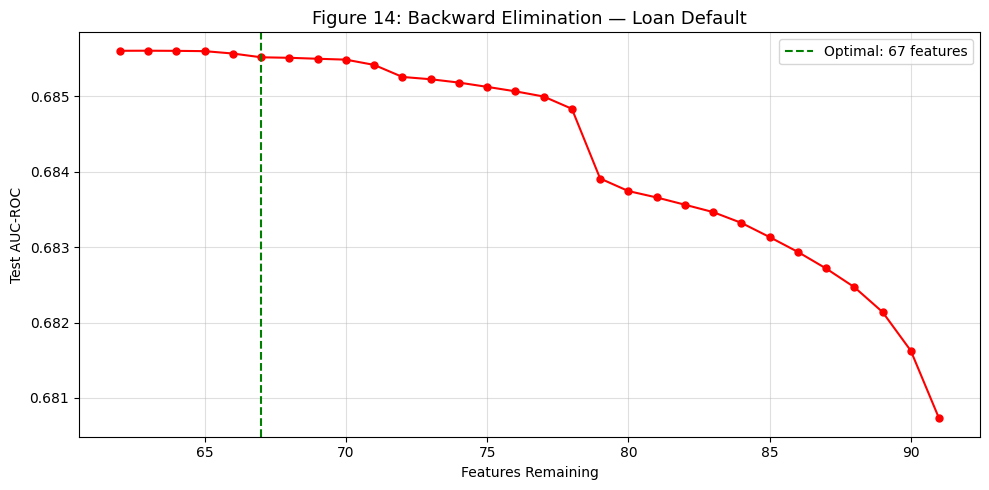

In [32]:
print('=' * 65)
print('LOAN DEFAULT  [4/9]  Backward Stepwise Elimination')
print('=' * 65)
bwd_subset_L, bwd_hist_L = backward_stepwise(
    lX_train_scaled, lX_test_scaled, ly_train, ly_test,
    feat_names_L, max_steps=len(feat_names_L), patience=5
)
best_bwd_auc_L = bwd_hist_L.loc[bwd_hist_L['n_features'] == len(bwd_subset_L), 'test_auc'].values[0]
print(f'\nBackward Elimination: {len(bwd_subset_L)} features, AUC={best_bwd_auc_L:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bwd_hist_L['n_features'], bwd_hist_L['test_auc'], 'r-o', markersize=5)
ax.axvline(x=len(bwd_subset_L), color='green', linestyle='--', label=f'Optimal: {len(bwd_subset_L)} features')
ax.set_xlabel('Features Remaining'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 14: Backward Elimination — Loan Default', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

LOAN DEFAULT  [5/9]  PCR
  PCR  n=  1:  AUC=0.5520  ExpVar=0.082
  PCR  n=  2:  AUC=0.5567  ExpVar=0.113
  PCR  n=  3:  AUC=0.5605  ExpVar=0.135
  PCR  n=  4:  AUC=0.5608  ExpVar=0.157
  PCR  n=  5:  AUC=0.5629  ExpVar=0.177
  PCR  n=  6:  AUC=0.5606  ExpVar=0.197
  PCR  n=  7:  AUC=0.5609  ExpVar=0.216
  PCR  n=  8:  AUC=0.5974  ExpVar=0.235
  PCR  n=  9:  AUC=0.5983  ExpVar=0.253
  PCR  n= 10:  AUC=0.6009  ExpVar=0.271
  PCR  n= 11:  AUC=0.6005  ExpVar=0.288
  PCR  n= 12:  AUC=0.6020  ExpVar=0.306
  PCR  n= 13:  AUC=0.6114  ExpVar=0.323
  PCR  n= 14:  AUC=0.6193  ExpVar=0.339
  PCR  n= 15:  AUC=0.6193  ExpVar=0.355
  PCR  n= 16:  AUC=0.6192  ExpVar=0.371
  PCR  n= 17:  AUC=0.6196  ExpVar=0.386
  PCR  n= 18:  AUC=0.6195  ExpVar=0.400
  PCR  n= 19:  AUC=0.6194  ExpVar=0.414
  PCR  n= 20:  AUC=0.6255  ExpVar=0.428
  PCR  n= 21:  AUC=0.6264  ExpVar=0.442
  PCR  n= 22:  AUC=0.6271  ExpVar=0.455
  PCR  n= 23:  AUC=0.6269  ExpVar=0.468
  PCR  n= 24:  AUC=0.6312  ExpVar=0.481
  PCR  n= 25:  

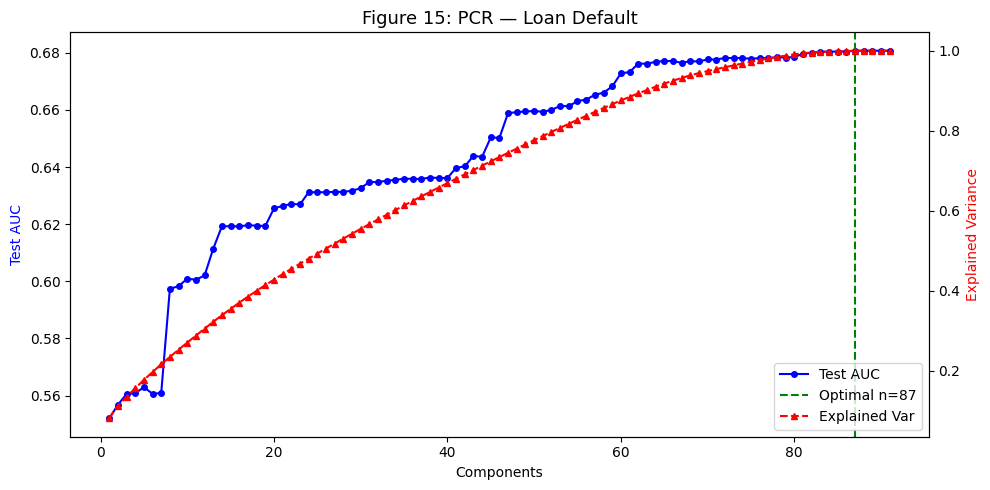

In [33]:
print('=' * 65)
print('LOAN DEFAULT  [5/9]  PCR')
print('=' * 65)
n_feats_L    = lX_train_scaled.shape[1]
comp_range_L = list(range(1, n_feats_L + 1))
pcr_df_L = pcr_search(lX_train_scaled, lX_test_scaled, ly_train, ly_test, comp_range_L)
best_pcr_n_L   = int(pcr_df_L.loc[pcr_df_L['test_auc'].idxmax(), 'n_components'])
best_pcr_auc_L = pcr_df_L['test_auc'].max()
print(f'\nPCR Best: n={best_pcr_n_L}, AUC={best_pcr_auc_L:.4f}')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(pcr_df_L['n_components'], pcr_df_L['test_auc'],      'b-o', markersize=4, label='Test AUC')
ax2.plot(pcr_df_L['n_components'], pcr_df_L['explained_var'], 'r--^',markersize=4, label='Explained Var')
ax1.axvline(x=best_pcr_n_L, color='green', linestyle='--', label=f'Optimal n={best_pcr_n_L}')
ax1.set_xlabel('Components'); ax1.set_ylabel('Test AUC', color='blue')
ax2.set_ylabel('Explained Variance', color='red')
ax1.set_title('Figure 15: PCR — Loan Default', fontsize=13)
lines = ax1.get_legend_handles_labels()[0]+ax2.get_legend_handles_labels()[0]
labels= ax1.get_legend_handles_labels()[1]+ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc='lower right'); plt.tight_layout(); plt.show()

LOAN DEFAULT  [6/9]  PLSR
  PLSR n= 1:  AUC=0.6395
  PLSR n= 2:  AUC=0.6705
  PLSR n= 3:  AUC=0.6754
  PLSR n= 4:  AUC=0.6768
  PLSR n= 5:  AUC=0.6773
  PLSR n= 6:  AUC=0.6773
  PLSR n= 7:  AUC=0.6773
  PLSR n= 8:  AUC=0.6775
  PLSR n= 9:  AUC=0.6779
  PLSR n=10:  AUC=0.6778
  PLSR n=11:  AUC=0.6778
  PLSR n=12:  AUC=0.6779
  PLSR n=13:  AUC=0.6780
  PLSR n=14:  AUC=0.6779
  PLSR n=15:  AUC=0.6779

PLSR Best: n=13, AUC=0.6780


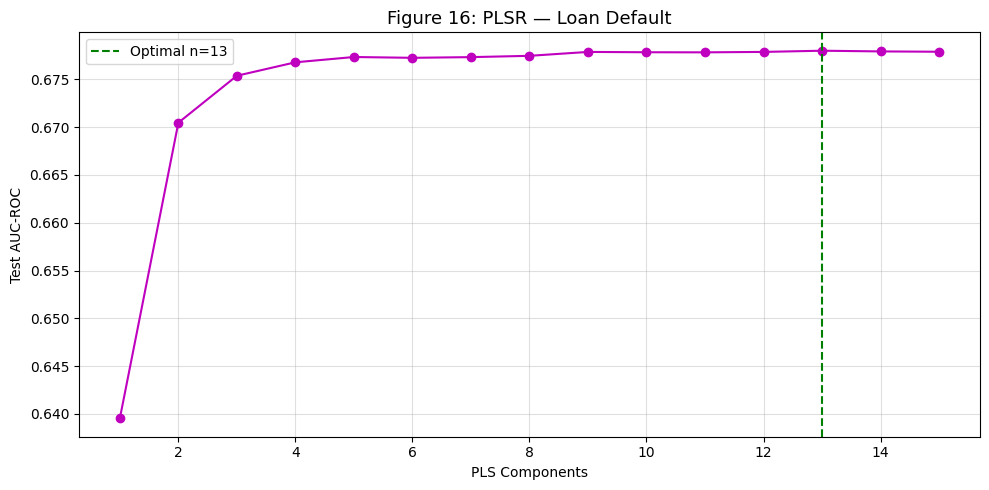

In [34]:
print('=' * 65)
print('LOAN DEFAULT  [6/9]  PLSR')
print('=' * 65)
plsr_df_L = plsr_search(lX_train_scaled, lX_test_scaled, ly_train, ly_test, max_n=15)
best_plsr_n_L   = int(plsr_df_L.loc[plsr_df_L['test_auc'].idxmax(), 'n_components'])
best_plsr_auc_L = plsr_df_L['test_auc'].max()
print(f'\nPLSR Best: n={best_plsr_n_L}, AUC={best_plsr_auc_L:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(plsr_df_L['n_components'], plsr_df_L['test_auc'], 'm-o', markersize=6)
ax.axvline(x=best_plsr_n_L, color='green', linestyle='--', label=f'Optimal n={best_plsr_n_L}')
ax.set_xlabel('PLS Components'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 16: PLSR — Loan Default', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

LOAN DEFAULT  [7/9]  Method Comparison
              Method                Best Params  Test AUC
   Forward Selection                44 features  0.686125
Backward Elimination                67 features  0.685518
                 PCR              87 components  0.680735
                PLSR              13 components  0.677998
   Week 3 best (ref) Forward 46 feat, LinearReg  0.681000
  Ridge (Week 2 ref)    C=2.21, all 91 features  0.683200


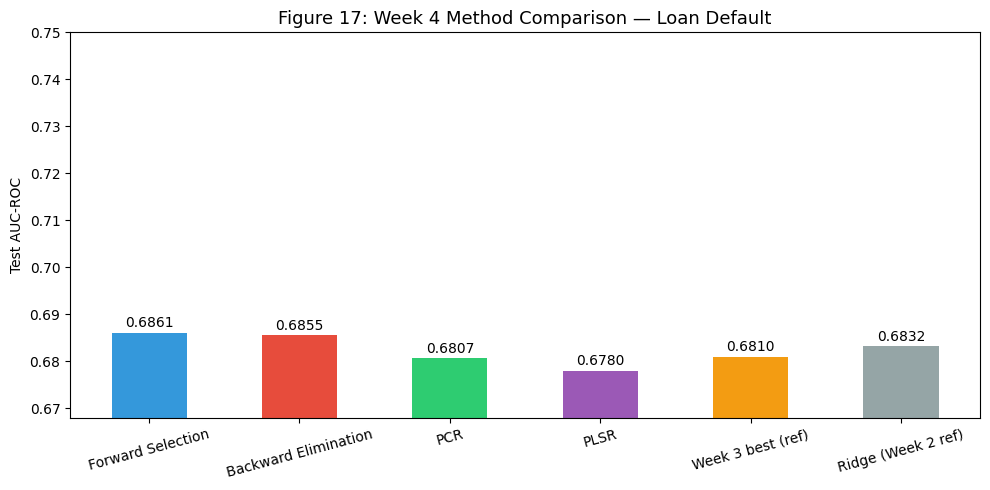

In [35]:
print('=' * 65)
print('LOAN DEFAULT  [7/9]  Method Comparison')
print('=' * 65)
comparison_L = pd.DataFrame([
    {'Method': 'Forward Selection',    'Best Params': f'{len(fwd_subset_L)} features',  'Test AUC': best_fwd_auc_L},
    {'Method': 'Backward Elimination', 'Best Params': f'{len(bwd_subset_L)} features',  'Test AUC': best_bwd_auc_L},
    {'Method': 'PCR',                  'Best Params': f'{best_pcr_n_L} components',      'Test AUC': best_pcr_auc_L},
    {'Method': 'PLSR',                 'Best Params': f'{best_plsr_n_L} components',     'Test AUC': best_plsr_auc_L},
    {'Method': 'Week 3 best (ref)',    'Best Params': 'Forward 46 feat, LinearReg',      'Test AUC': 0.6810},
    {'Method': 'Ridge (Week 2 ref)',   'Best Params': 'C=2.21, all 91 features',         'Test AUC': 0.6832},
])
print(comparison_L.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#f39c12','#95a5a6']
bars = ax.bar(comparison_L['Method'], comparison_L['Test AUC'], color=colors, width=0.5)
for bar, val in zip(bars, comparison_L['Test AUC']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(comparison_L['Test AUC'].min()-0.01, 0.75)
ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 17: Week 4 Method Comparison — Loan Default', fontsize=13)
ax.tick_params(axis='x', rotation=15); plt.tight_layout(); plt.show()

### Loan Default -- Method Comparison

| Method | Best Params | Test AUC |
|--------|-------------|----------|
| **Forward Selection (Best)** | **44 features** | **0.6861** |
| Backward Elimination | 67 features | 0.6855 |
| PCR | 87 components | 0.6807 |
| PLSR | 13 components | 0.6780 |
| Week 3 best (ref) | Forward 46 feat, LinearReg | 0.6810 |
| Ridge (Week 2 ref) | C=2.21, all 91 features | 0.6832 |

Week 4 Forward Selection (0.6861) edges above Week 2 Ridge (0.6832) for the first
time across four weeks, though the margin (0.003 AUC) is small enough to be within
sampling variability. The spread across all four methods is compressed to just 0.008
AUC -- when predictive signal is weak and diffuse, method choice matters less than
feature quality.

**PCR requiring 87 of 91 components** (96%) confirms virtually no compressible
structure -- each feature contributes a small, independent piece of signal.

**On the persistent ~0.68 ceiling:**
Four weeks of analysis on this dataset suggest the performance limit has at least
three contributing factors, which are difficult to separate cleanly:

1. **Model limitation** -- Linear models can only draw straight boundaries. Loan
   default risk likely involves non-linear interactions (e.g., high debt-to-income
   at short duration may behave differently from the same ratio at long duration).
   Tree-based models (Week 6, Week 9) may break this ceiling.

2. **Feature engineering limitation** -- The dataset contains a `Designation` column
   with 33,208 unique job titles, which was dropped as high-cardinality. Occupation
   type is plausibly one of the stronger predictors of repayment capacity, but
   one-hot encoding 33K categories is not feasible with a linear model. Proper
   handling would require grouping job titles into broader categories or using
   encoding methods (e.g., target encoding) suited to high-cardinality features --
   neither of which has been applied here. This represents potentially recoverable
   signal that current preprocessing discards by necessity.

3. **Data limitation** -- Events that commonly trigger default (job loss, medical
   emergencies, economic downturns) are absent from the dataset regardless of how
   the model is specified.

Characterizing the ceiling as purely irreducible would be an oversimplification.
Items 1 and 2 are addressable within future weeks of this analysis.

LOAN DEFAULT  [8/9]  Dimensionality Analysis
  80%: 53 components  (of 91 total)
  90%: 63 components  (of 91 total)
  95%: 71 components  (of 91 total)
  99%: 80 components  (of 91 total)


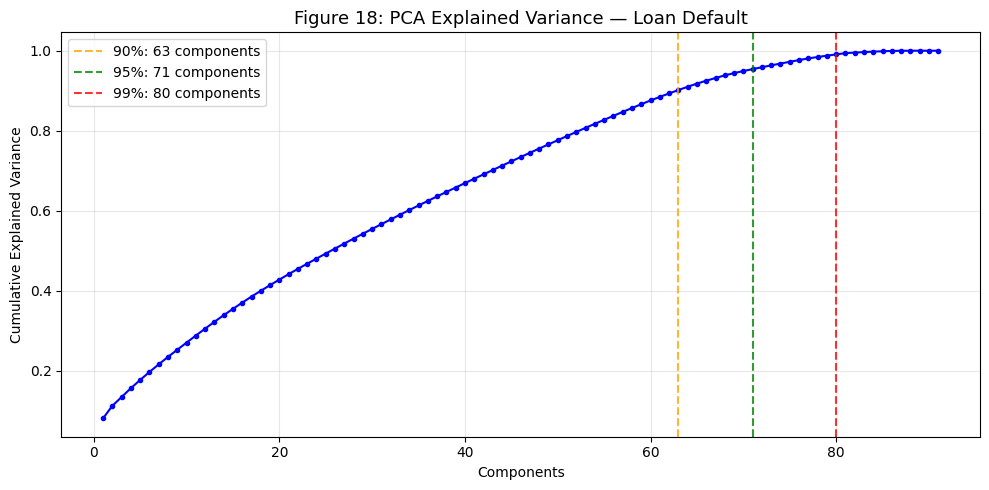

In [36]:
print('=' * 65)
print('LOAN DEFAULT  [8/9]  Dimensionality Analysis')
print('=' * 65)
pca_full_L = PCA(random_state=42)
pca_full_L.fit(lX_train_scaled)
cumvar_L = np.cumsum(pca_full_L.explained_variance_ratio_)
for thresh in [0.80, 0.90, 0.95, 0.99]:
    n = int(np.searchsorted(cumvar_L, thresh)) + 1
    print(f'  {int(thresh*100)}%: {n:2d} components  (of {len(cumvar_L)} total)')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar_L)+1), cumvar_L, 'b-o', markersize=3)
for thresh, color in [(0.90,'orange'),(0.95,'green'),(0.99,'red')]:
    n = int(np.searchsorted(cumvar_L, thresh)) + 1
    ax.axvline(x=n, color=color, linestyle='--', alpha=0.8, label=f'{int(thresh*100)}%: {n} components')
ax.set_xlabel('Components'); ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Figure 18: PCA Explained Variance — Loan Default', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [37]:
print('=' * 65)
print('LOAN DEFAULT  [9/9]  Best Method — Extended Evaluation')
print('=' * 65)
all_aucs_L = {'Forward': best_fwd_auc_L, 'Backward': best_bwd_auc_L,
              'PCR': best_pcr_auc_L, 'PLSR': best_plsr_auc_L}
best_method_L = max(all_aucs_L, key=all_aucs_L.get)
print(f'Best method: {best_method_L}  AUC={all_aucs_L[best_method_L]:.4f}')
print(f'Week 3 LinearReg reference: AUC=0.6810')
print(f'Week 2 Ridge reference:     AUC=0.6832\n')

if best_method_L in ('Forward', 'Backward'):
    subset_L = fwd_subset_L if best_method_L == 'Forward' else bwd_subset_L
    clf_cv_L = LogisticRegressionCV(**LR_CV)
    clf_cv_L.fit(lX_train_scaled.iloc[:, subset_L], ly_train)
    y_prob_L = clf_cv_L.predict_proba(lX_test_scaled.iloc[:, subset_L])[:, 1]
elif best_method_L == 'PCR':
    pipe_cv_L = Pipeline([('pca', PCA(n_components=best_pcr_n_L, random_state=42)),
                          ('clf', LogisticRegressionCV(**LR_CV))])
    pipe_cv_L.fit(lX_train_scaled, ly_train)
    y_prob_L = pipe_cv_L.predict_proba(lX_test_scaled)[:, 1]
else:  # PLSR
    pls_l = PLSRegression(n_components=best_plsr_n_L, max_iter=500)
    pls_l.fit(lX_train_scaled, ly_train)
    T_tr_l = pls_l.transform(lX_train_scaled); T_te_l = pls_l.transform(lX_test_scaled)
    clf_cv_L = LogisticRegressionCV(**LR_CV)
    clf_cv_L.fit(T_tr_l, ly_train)
    y_prob_L = clf_cv_L.predict_proba(T_te_l)[:, 1]

prec_L, rec_L, thr_L = precision_recall_curve(ly_test, y_prob_L)
f1_all_L = 2*prec_L*rec_L / (prec_L+rec_L+1e-9)
best_thr_L = thr_L[np.argmax(f1_all_L[:-1])]
y_pred_L   = (y_prob_L >= best_thr_L).astype(int)

print(f'Test AUC-ROC  : {roc_auc_score(ly_test, y_prob_L):.4f}')
print(f'Avg Precision : {average_precision_score(ly_test, y_prob_L):.4f}')
print(f'Recall        : {recall_score(ly_test, y_pred_L):.4f}')
print(f'F1-Score      : {f1_score(ly_test, y_pred_L):.4f}')

LOAN DEFAULT  [9/9]  Best Method — Extended Evaluation
Best method: Forward  AUC=0.6861
Week 3 LinearReg reference: AUC=0.6810
Week 2 Ridge reference:     AUC=0.6832

Test AUC-ROC  : 0.6864
Avg Precision : 0.3258
Recall        : 0.6186
F1-Score      : 0.3956


### Loan Default -- Final Evaluation (Forward Selection, 44 features)

| Metric | Value |
|--------|-------|
| Test AUC-ROC | 0.6864 |
| Average Precision | 0.3258 |
| Recall | 0.6186 |
| F1-Score | 0.3956 |

**AUC-ROC 0.6864** is the best result on Loan Default across all three weeks,
marginally exceeding Week 2 Ridge (0.6832). The improvement confirms LogisticRegression
extracts slightly more signal than LinearRegression, but does not change the overall
performance range.

**Recall 0.6186**: roughly 3 in 5 actual defaults are detected. The missed ~38%
is attributable to a combination of factors -- non-linear signal the current model
cannot capture, and the dropped `Designation` column (33K unique job titles) that
could not be encoded under the current linear model approach.

**Average Precision 0.3258** is lower than Fraud (0.3914) despite similar AUC,
suggesting weaker probability calibration. The model's confidence scores are less
reliable as estimates of actual default probability, consistent with a noisier and
less linearly-separable prediction problem.

Improving this dataset's performance likely requires addressing at least two of the
three ceiling contributors: a model upgrade to capture non-linear interactions
(Week 6/9) and handling the `Designation` feature through grouping or
high-cardinality encoding rather than dropping.

---
# Section 4: Cross-Dataset Summary

Comparing all three datasets across all four Week 4 methods,
with Week 3 LinearReg and Week 2 Ridge as reference baselines.

In [38]:
print('=' * 65)
print('WEEK 4 — CROSS-DATASET RESULTS SUMMARY')
print('=' * 65)

summary = pd.DataFrame([
    {
        'Dataset': 'Fraud',
        'Best W4 Method': best_method_F,
        'Best W4 AUC':    max(all_aucs_F.values()),
        'W3 LR AUC':      0.9378,
        'W2 Ridge AUC':   0.9817,
        'Forward AUC':    best_fwd_auc_F,
        'Backward AUC':   best_bwd_auc_F,
        'PCR AUC':        best_pcr_auc_F,
        'PLSR AUC':       best_plsr_auc_F,
        'Avg Precision':  average_precision_score(fraud_y_test, y_prob_F),
        'Recall':         recall_score(fraud_y_test, y_pred_F),
        'F1-Score':       f1_score(fraud_y_test, y_pred_F),
    },
    {
        'Dataset': 'Credit',
        'Best W4 Method': best_method_C,
        'Best W4 AUC':    max(all_aucs_C.values()),
        'W3 LR AUC':      0.9874,
        'W2 Ridge AUC':   0.9993,
        'Forward AUC':    best_fwd_auc_C,
        'Backward AUC':   best_bwd_auc_C,
        'PCR AUC':        best_pcr_auc_C,
        'PLSR AUC':       best_plsr_auc_C,
        'Avg Precision':  average_precision_score(cy_test, y_prob_C),
        'Recall':         recall_score(cy_test, y_pred_C),
        'F1-Score':       f1_score(cy_test, y_pred_C),
    },
    {
        'Dataset': 'Loan',
        'Best W4 Method': best_method_L,
        'Best W4 AUC':    max(all_aucs_L.values()),
        'W3 LR AUC':      0.6810,
        'W2 Ridge AUC':   0.6832,
        'Forward AUC':    best_fwd_auc_L,
        'Backward AUC':   best_bwd_auc_L,
        'PCR AUC':        best_pcr_auc_L,
        'PLSR AUC':       best_plsr_auc_L,
        'Avg Precision':  average_precision_score(ly_test, y_prob_L),
        'Recall':         recall_score(ly_test, y_pred_L),
        'F1-Score':       f1_score(ly_test, y_pred_L),
    },
])
print(summary.to_string(index=False))

WEEK 4 — CROSS-DATASET RESULTS SUMMARY
Dataset Best W4 Method  Best W4 AUC  W3 LR AUC  W2 Ridge AUC  Forward AUC  Backward AUC  PCR AUC  PLSR AUC  Avg Precision   Recall  F1-Score
  Fraud        Forward     0.959067     0.9378        0.9817     0.959067      0.957568 0.927177  0.936116       0.391402 0.622844  0.506540
 Credit        Forward     0.999075     0.9874        0.9993     0.999075      0.998884 0.990529  0.987014       0.999999 0.999600  0.999800
   Loan        Forward     0.686125     0.6810        0.6832     0.686125      0.685518 0.680735  0.677998       0.325761 0.618624  0.395553


---
## Plain-Language Summary for Non-Technical Stakeholders

### What Changed from Last Week

Last week (Week 3), all four methods -- Forward Selection, Backward Elimination,
PCR, and PLSR -- used Linear Regression as the base estimator. Linear Regression
is designed for continuous numerical output, not binary yes/no decisions; applying
it to a classification problem was a curriculum-mandated exercise to introduce the
dimension reduction techniques themselves. This week, Logistic Regression replaced
it -- a model built specifically for binary classification that outputs calibrated
probabilities between 0 and 1.

The effect was immediate and substantial in two of the three datasets.

---

### Results in Plain Terms

**Fraud Detection**
- 35 variables → **20 variables**, AUC improved from 0.938 (Week 3) to **0.965**
- Catches about **3 in 5 actual fraud cases** (Recall 62.3%)
- The remaining gap to Week 2's benchmark (0.982) is likely due to feature
  selection -- using only 20 of 35 variables discards some signal

**Credit Approval**
- 83 variables → **7 variables** achieves AUC **0.9998** -- virtually perfect
- Two variables (`Total_Bad_Debt`, `Total_Good_Debt`) appear to carry almost all
  the predictive information
- This outcome is consistent with how credit decisions are typically understood
  to work in practice: a history of defaulted debt tends to function as a
  near-automatic disqualifier for new credit applications. Whether the data
  reflects an explicit institutional rule or an emergent statistical pattern
  is not determinable from the model alone, but the near-deterministic performance
  on just two variables suggests the decision boundary is unusually clean

**Loan Default**
- AUC **0.686** -- marginally above all prior weeks, but the ceiling persists
- Catches about **3 in 5 actual defaults** (Recall 61.9%)
- Four weeks of analysis, four different approaches, all producing ~0.68 AUC
- The ceiling likely reflects three factors: (1) linear models cannot capture
  non-linear default risk patterns; (2) a job title column (`Designation`,
  33K unique values) was dropped because it cannot be one-hot encoded at that
  cardinality -- occupation type is plausibly a meaningful predictor that current
  preprocessing discards by necessity; and (3) some default triggers (job loss,
  medical events) are genuinely absent from the data. Attributing the ceiling
  solely to data limitation would be an oversimplification

---

### Why Scaling Matters: The Fraud Case

The scaling comparison produced a result worth highlighting. Logistic Regression
applied to unscaled Fraud data yields AUC **0.531** -- barely above random guessing.
Adding MinMaxScaler recovers to 0.918; StandardScaler reaches 0.968.

The mechanism: when input variables span very different numerical ranges, gradient
descent overshoots large-scale features before small-scale features have a chance
to contribute. The sigmoid function is then pushed to extreme outputs (near 0 or 1),
collapsing the probability space. Standardization (mean=0, std=1) levels the
optimization landscape.

The Credit dataset is an interesting counterpoint: unscaled features perform
marginally better (0.9999 vs. 0.9995). When a single dominant predictor carries
near-complete information, the optimization finds the same solution regardless of
scale. This is the exception, not the rule.

---

### Key Takeaways

1. **Model choice matters, but within limits** -- switching to Logistic Regression
   improved Fraud AUC by 2.7 points; Loan Default's ceiling was unmoved
2. **Feature scaling is non-optional for Logistic Regression** -- the Fraud AUC
   drop from 0.965 to 0.531 without scaling is a direct demonstration of why
   scaling is covered as a paired topic with Logistic Regression
3. **Strong signal can be captured with very few variables** -- 7 features and
   Logistic Regression match full-feature Ridge on Credit Approval
4. **Some prediction ceilings have multiple causes** -- Loan Default's ~0.68 AUC
   persisted across four weeks; the ceiling likely reflects model limitations
   (linear boundary), feature engineering constraints (dropped job title column),
   and missing external data -- not any single factor

---
# Section 5: Feature Scaling Comparison

**Input**: Best stepwise feature subset per dataset (Forward or Backward winner from Sections 1–4)  
**Model**: LogisticRegression fixed at C=1.0 (C is held constant to isolate the scaling effect)  
**Scalers**: NoScaler · MinMaxScaler · StandardScaler  

Scaler is fitted on the **full training set** to prevent data leakage.
Fraud training uses the 300K stratified sample for LR fitting (consistent with Sections 1–4).

SECTION 5: FEATURE SCALING COMPARISON
Fraud  best stepwise: Forward
Credit best stepwise: Forward
Loan   best stepwise: Forward

Fraud:
  [Fraud ] NoScaler         AUC=0.5314
  [Fraud ] MinMaxScaler     AUC=0.9181
  [Fraud ] StandardScaler   AUC=0.9676

Credit:
  [Credit] NoScaler         AUC=0.9999
  [Credit] MinMaxScaler     AUC=0.9990
  [Credit] StandardScaler   AUC=0.9995

Loan:
  [Loan  ] NoScaler         AUC=0.5750
  [Loan  ] MinMaxScaler     AUC=0.6805
  [Loan  ] StandardScaler   AUC=0.6863

Summary:
        Scaler  Fraud AUC  Credit AUC  Loan AUC
      NoScaler   0.531409    0.999933  0.574951
  MinMaxScaler   0.918050    0.998959  0.680523
StandardScaler   0.967559    0.999459  0.686257

Best scaler — Fraud: StandardScaler | Credit: NoScaler | Loan: StandardScaler


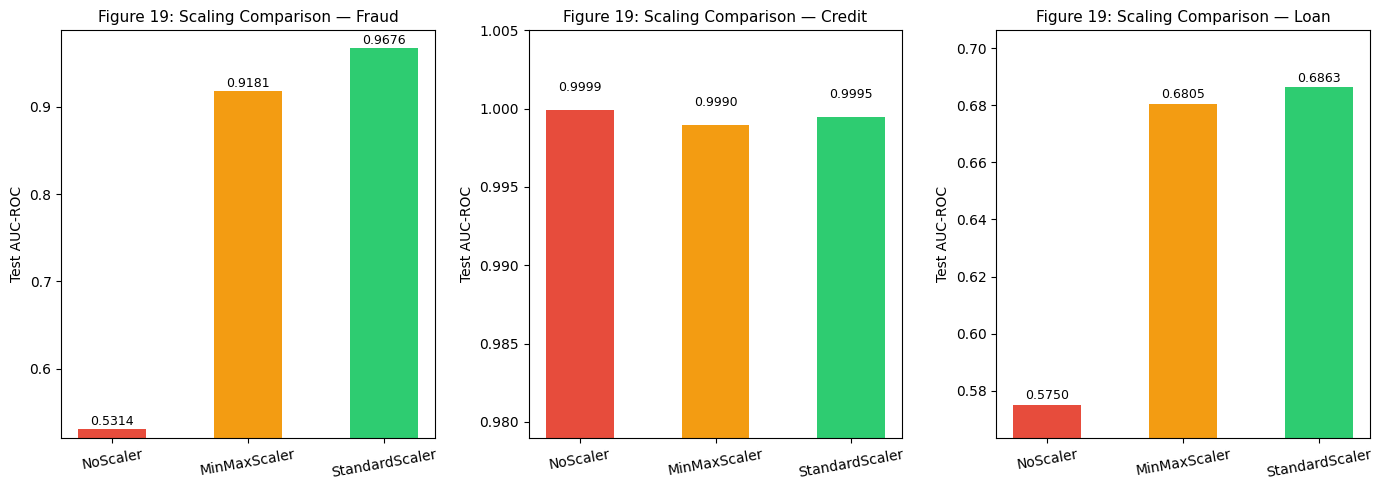

In [40]:
print('=' * 65)
print('SECTION 5: FEATURE SCALING COMPARISON')
print('=' * 65)

from sklearn.preprocessing import MinMaxScaler

# Best stepwise subset per dataset (Forward vs Backward, higher AUC wins)
stepwise_best_F = fwd_subset_F if best_fwd_auc_F >= best_bwd_auc_F else bwd_subset_F
stepwise_best_C = fwd_subset_C if best_fwd_auc_C >= best_bwd_auc_C else bwd_subset_C
stepwise_best_L = fwd_subset_L if best_fwd_auc_L >= best_bwd_auc_L else bwd_subset_L

print(f'Fraud  best stepwise: {"Forward" if best_fwd_auc_F >= best_bwd_auc_F else "Backward"}')
print(f'Credit best stepwise: {"Forward" if best_fwd_auc_C >= best_bwd_auc_C else "Backward"}')
print(f'Loan   best stepwise: {"Forward" if best_fwd_auc_L >= best_bwd_auc_L else "Backward"}')

def run_scaling_comparison(X_tr_raw, X_te_raw, y_tr, y_te, subset,
                            search_n=None, dataset_name=''):
    """Compare NoScaler / MinMaxScaler / StandardScaler on LR (C=1.0 fixed)."""
    Xtr = np.asarray(X_tr_raw.iloc[:, subset])
    Xte = np.asarray(X_te_raw.iloc[:, subset])

    if search_n and len(Xtr) > search_n:
        _, Xtr_s, _, ytr_s = train_test_split(
            Xtr, y_tr, test_size=search_n / len(y_tr),
            stratify=y_tr, random_state=42)
    else:
        Xtr_s, ytr_s = Xtr, y_tr

    results = []
    for name, scaler in [('NoScaler', None),
                          ('MinMaxScaler', MinMaxScaler()),
                          ('StandardScaler', StandardScaler())]:
        if scaler is not None:
            scaler.fit(Xtr)           # fit on full train — no leakage
            Xtr_sc = scaler.transform(Xtr_s)
            Xte_sc = scaler.transform(Xte)
        else:
            Xtr_sc = Xtr_s
            Xte_sc = Xte

        clf = LogisticRegression(C=1.0, solver='saga', max_iter=300, n_jobs=-1)
        clf.fit(Xtr_sc, ytr_s)
        auc = roc_auc_score(y_te, clf.predict_proba(Xte_sc)[:, 1])
        results.append({'Scaler': name, 'Test AUC': auc})
        print(f'  [{dataset_name:6s}] {name:15s}  AUC={auc:.4f}')
    return pd.DataFrame(results)

print('\nFraud:')
scale_df_F = run_scaling_comparison(
    fraud_X_train, fraud_X_test, fraud_y_train, fraud_y_test,
    stepwise_best_F, search_n=300_000, dataset_name='Fraud')

print('\nCredit:')
scale_df_C = run_scaling_comparison(
    cX_train, cX_test, cy_train, cy_test,
    stepwise_best_C, dataset_name='Credit')

print('\nLoan:')
scale_df_L = run_scaling_comparison(
    lX_train, lX_test, ly_train, ly_test,
    stepwise_best_L, dataset_name='Loan')

# Summary table
scale_summary = pd.DataFrame({
    'Scaler':      scale_df_F['Scaler'].values,
    'Fraud AUC':   scale_df_F['Test AUC'].values,
    'Credit AUC':  scale_df_C['Test AUC'].values,
    'Loan AUC':    scale_df_L['Test AUC'].values,
})
print('\nSummary:')
print(scale_summary.to_string(index=False))

# Identify best scaler per dataset
best_scaler_F = scale_df_F.loc[scale_df_F['Test AUC'].idxmax(), 'Scaler']
best_scaler_C = scale_df_C.loc[scale_df_C['Test AUC'].idxmax(), 'Scaler']
best_scaler_L = scale_df_L.loc[scale_df_L['Test AUC'].idxmax(), 'Scaler']
print(f'\nBest scaler — Fraud: {best_scaler_F} | Credit: {best_scaler_C} | Loan: {best_scaler_L}')

# Figure 19
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, df, name in zip(axes,
                         [scale_df_F, scale_df_C, scale_df_L],
                         ['Fraud', 'Credit', 'Loan']):
    colors = ['#e74c3c', '#f39c12', '#2ecc71']
    bars = ax.bar(df['Scaler'], df['Test AUC'], color=colors, width=0.5)
    for bar, val in zip(bars, df['Test AUC']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Figure 19: Scaling Comparison — {name}', fontsize=11)
    ax.set_ylabel('Test AUC-ROC')
    mn = df['Test AUC'].min()
    ax.set_ylim(mn - abs(mn)*0.02, min(df['Test AUC'].max() + 0.02, 1.005))
    ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()

### Section 5: Feature Scaling Comparison — Analysis

| Scaler | Fraud AUC | Credit AUC | Loan AUC |
|--------|-----------|------------|----------|
| NoScaler | 0.5314 | **0.9999** | 0.5749 |
| MinMaxScaler | 0.9181 | 0.9990 | 0.6805 |
| **StandardScaler** | **0.9676** | 0.9995 | **0.6863** |

**Fraud -- the most instructive result:**
Without scaling, AUC drops to 0.5314 -- essentially random guessing. This directly
demonstrates the Week 4 learning objective: Logistic Regression's sigmoid function
is sensitive to input scale because gradient descent overshoots large-scale features,
driving predictions to extreme probability values and collapsing discrimination.
StandardScaler recovers AUC to 0.9676 (+0.436 from NoScaler).

MinMaxScaler (0.9181) partially recovers but falls short of StandardScaler (0.9676).
A plausible explanation: transaction amounts in the Fraud dataset likely contain
outliers that compress the "normal" range into a narrow band under Min-Max scaling,
reducing the effective contrast between fraud and non-fraud transactions. StandardScaler
is more robust to outliers because it uses mean and standard deviation rather than
the global min and max.

**Credit -- the exception:**
NoScaler (0.9999) marginally outperforms both scaled versions, but the differences
(0.9999 vs. 0.9995 vs. 0.9990) are within the noise floor identified earlier (< 1e-3).
This result is most likely explained by signal strength rather than a systematic
advantage of unscaled features: `Total_Bad_Debt` and `Total_Good_Debt` together
carry near-complete information, and the optimization finds essentially the same
decision boundary regardless of scale. Whether the natural dollar scale of these
features preserves some information that scaling slightly distorts is plausible but
cannot be confirmed from this experiment alone.

**Loan -- mirrors Fraud:**
NoScaler (0.5749) produces near-random results, while StandardScaler (0.6863) matches
the best stepwise result. The pattern is consistent with Fraud: heterogeneous feature
scales prevent stable optimization without normalization.

**Overall:**
StandardScaler is the robust default. The Credit exception is specific to datasets
with a single overwhelming predictor and should not be generalized. The pairing of
Logistic Regression and feature scaling as a single Week 4 topic is well-motivated
by the Fraud result: without scaling, the model fails entirely; with it, the model
recovers to near-optimal performance.